# Broadcast Attendance Analysis — Shortlist Players

Focuses on players who have a real shot at the top 10: those with **P(top-10) > 5%**,
where P(top-10) = p_participate × P_top10_given_play from the latest MC simulation.

Questions:
1. How do broadcast tournament features affect attendance for this elite group?
2. What is each individual player's sensitivity to each feature?

In [1]:
import sys, sqlite3
sys.path.insert(0, '..')
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from src.config import DB_PATH
from broadcast_attendance_features import (
    load_data, classify_events, build_player_lookup, match_participants,
    compute_event_level_features, compute_player_level_features, compute_rolling_baseline
)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11})

## 1  Shortlist: players with P(top-10) > 5%

In [2]:
P_TOP10_THRESHOLD = 0.05   # change to explore

conn = sqlite3.connect(DB_PATH)
preds = pd.read_sql_query(
    "SELECT username, p_participate, P_top1_given_play, P_top3_given_play, "
    "P_top5_given_play, P_top8_given_play, P_top10_given_play, tourn_date "
    "FROM latest_model_predictions",
    conn
)
conn.close()

preds['p_top10'] = preds['p_participate'] * preds['P_top10_given_play']
preds['p_top3']  = preds['p_participate'] * preds['P_top3_given_play']
preds['p_top1']  = preds['p_participate'] * preds['P_top1_given_play']

shortlist = preds[preds['p_top10'] >= P_TOP10_THRESHOLD].sort_values('p_top10', ascending=False).reset_index(drop=True)
shortlist_users = set(shortlist['username'])

print(f"Tourn date: {preds['tourn_date'].iloc[0]}")
print(f"Shortlist: {len(shortlist)} players with P(top-10) >= {P_TOP10_THRESHOLD:.0%}\n")

display_cols = ['username', 'p_participate', 'P_top10_given_play', 'p_top10',
                'P_top3_given_play', 'p_top3', 'P_top1_given_play', 'p_top1']
pd.set_option('display.float_format', '{:.4f}'.format)
shortlist[display_cols]

Tourn date: 2026-07-14
Shortlist: 46 players with P(top-10) >= 5%



,username,p_participate,P_top10_given_play,p_top10,P_top3_given_play,p_top3,P_top1_given_play,p_top1
0,Hikaru,0.8798,0.5129,0.4513,0.1823,0.1604,0.0641,0.0564
1,mishanick,0.9742,0.3685,0.3590,0.1196,0.1165,0.0406,0.0396
2,DenLaz,0.8322,0.3966,0.3301,0.1310,0.1090,0.0440,0.0366
3,GHANDEEVAM2003,0.6651,0.4755,0.3162,0.1637,0.1089,0.0568,0.0378
4,Polish_fighter3000,0.8193,0.3479,0.2850,0.1105,0.0905,0.0369,0.0303
5,HansOnTwitch,0.5977,0.3953,0.2363,0.1294,0.0773,0.0430,0.0257
6,ChristopherYoo,0.7684,0.2736,0.2102,0.0863,0.0663,0.0292,0.0224
7,jefferyx,0.7848,0.2599,0.2040,0.0796,0.0625,0.0263,0.0206
8,Parhamov,0.8808,0.2290,0.2017,0.0693,0.0610,0.0234,0.0206
9,FairChess_on_YouTube,0.7424,0.2552,0.1895,0.0786,0.0584,0.0258,0.0192


## 2  Load broadcast data and compute features

In [3]:
SINCE           = '2020-01-01'
MIN_APPEARANCES = 8

print('Loading data...')
df_tt, df_events, df_rounds, df_parts, df_players = load_data(SINCE)
df_events = classify_events(df_events)
lookup = build_player_lookup(df_players)
df_parts_matched = match_participants(df_parts, lookup)

tt_dates_utc = pd.DatetimeIndex(df_tt['date'].sort_values().unique()).tz_localize('UTC')

print('Computing features...')
df_event_feats  = compute_event_level_features(tt_dates_utc, df_events, df_rounds)
df_player_feats = compute_player_level_features(tt_dates_utc, df_events, df_rounds, df_parts_matched)
df_pool         = compute_rolling_baseline(df_tt, MIN_APPEARANCES)

# Merge all features
df_pool = df_pool.merge(df_event_feats, on='date', how='left')
df_pool = df_pool.merge(df_player_feats, on=['username', 'date'], how='left')
for col in ['player_in_elite', 'player_in_prestige', 'player_round_tuesday']:
    df_pool[col] = df_pool[col].fillna(0).astype(int)

print(f"Full pool: {len(df_pool):,} (player, date) pairs, {df_pool['username'].nunique():,} players")

Loading data...


  Name match rate: 21.9% (99,181 / 452,519 participant rows)
Computing features...
  Computing event-level features...


  Computing player-level features (this may take a moment)...


  Computing rolling baseline attendance...


Full pool: 903,057 (player, date) pairs, 5,820 players


## 3  Shortlist pool: attendance by feature

In [4]:
df_sl = df_pool[df_pool['username'].isin(shortlist_users)].copy()
df_sl = df_sl.merge(shortlist[['username', 'p_top10', 'p_top3', 'p_top1']], on='username', how='left')

print(f"Shortlist pool: {len(df_sl):,} (player, date) pairs — {df_sl['username'].nunique()} players")
print(f"Overall attendance rate (shortlist): {df_sl['participated'].mean():.3f}")
print(f"Overall attendance rate (all players): {df_pool['participated'].mean():.3f}")

FEATURES = [
    ('n_elite_named',         'Named elite events ±7 days'),
    ('n_high_prestige',       'High-prestige OTB events ±7 days'),
    ('n_rounds_tuesday',      'Broadcast rounds on TT day'),
    ('elite_starts_within14', 'Elite event starts within 14 days'),
    ('player_in_elite',       'Player is IN elite event ±7 days'),
    ('player_in_prestige',    'Player is IN high-prestige event ±7 days'),
    ('player_round_tuesday',  'Player has round ON Tuesday'),
]
feat_cols = [f[0] for f in FEATURES]

rows = []
for col, label in FEATURES:
    g0 = df_sl[df_sl[col] == 0]
    g1 = df_sl[df_sl[col] >= 1]
    if g1.empty:
        continue
    r0, r1 = g0['participated'].mean(), g1['participated'].mean()
    # All-player comparison
    all_g0 = df_pool[df_pool[col] == 0]
    all_g1 = df_pool[df_pool[col] >= 1]
    all_r0, all_r1 = all_g0['participated'].mean(), (all_g1['participated'].mean() if not all_g1.empty else np.nan)
    rows.append({
        'Feature': label,
        'SL rate (=0)': r0, 'SL n=0': len(g0),
        'SL rate (>=1)': r1, 'SL n>=1': len(g1),
        'SL delta': r1 - r0,
        'All delta': all_r1 - all_r0,
    })

df_desc = pd.DataFrame(rows)
pd.set_option('display.float_format', '{:.3f}'.format)
df_desc

Shortlist pool: 15,209 (player, date) pairs — 45 players
Overall attendance rate (shortlist): 0.574
Overall attendance rate (all players): 0.270


,Feature,SL rate (=0),SL n=0,SL rate (>=1),SL n>=1,SL delta,All delta
0,Named elite events ±7 days,0.566,9238,0.587,5971,0.021,0.009
1,High-prestige OTB events ±7 days,0.527,7576,0.622,7633,0.095,0.065
2,Broadcast rounds on TT day,0.532,5436,0.598,9773,0.066,0.041
3,Elite event starts within 14 days,0.568,11987,0.599,3222,0.031,0.018
4,Player is IN elite event ±7 days,0.576,14941,0.455,268,-0.121,-0.028
5,Player is IN high-prestige event ±7 days,0.578,14704,0.473,505,-0.105,0.012
6,Player has round ON Tuesday,0.580,14962,0.215,247,-0.366,-0.183


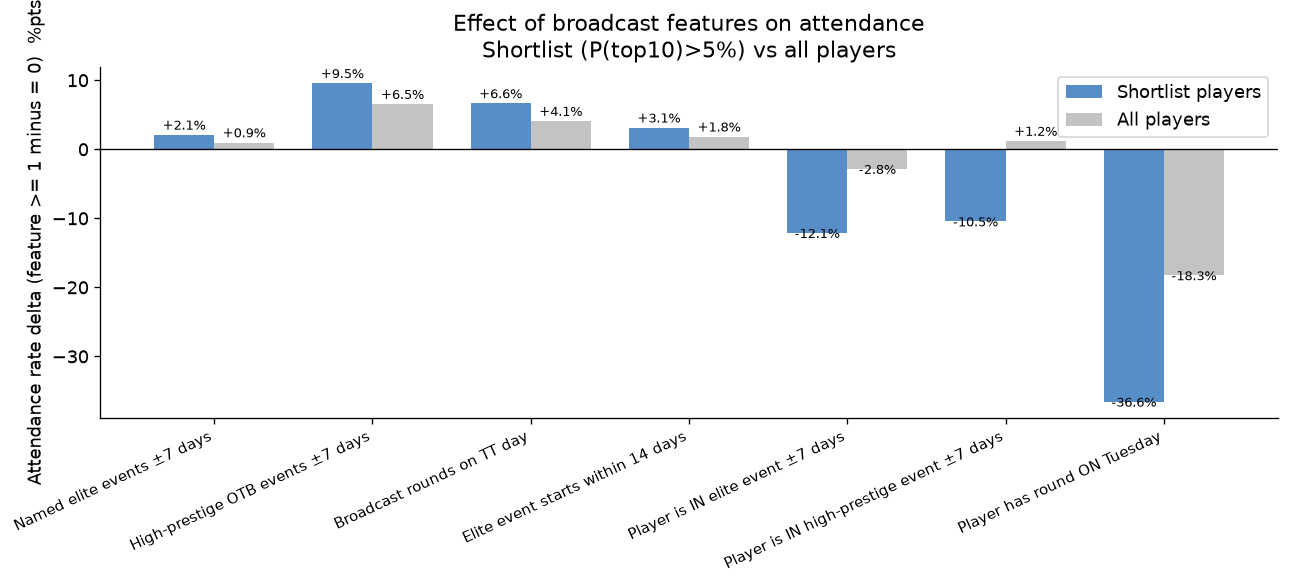

In [5]:
# Bar chart: attendance delta (feature=0 vs >=1) — shortlist vs all players
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(df_desc))
w = 0.38
bars_sl  = ax.bar(x - w/2, df_desc['SL delta']  * 100, w, label='Shortlist players', color='#3a7abf', alpha=0.85)
bars_all = ax.bar(x + w/2, df_desc['All delta'] * 100, w, label='All players',       color='#aaaaaa', alpha=0.70)

for bar in list(bars_sl) + list(bars_all):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + (0.3 if h >= 0 else -1.2),
            f'{h:+.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([r[1] for r in FEATURES], rotation=25, ha='right', fontsize=9)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Attendance rate delta (feature >= 1 minus = 0)  %pts')
ax.set_title('Effect of broadcast features on attendance\nShortlist (P(top10)>5%) vs all players')
ax.legend()
plt.tight_layout()
plt.show()

## 4  Individual player cards

For each shortlist player, shows:
- Model predictions (p_participate, P(top-k), unconditional P(top-k))
- Overall attendance rate and sample sizes
- Attendance delta for each broadcast feature
- Attendance timeline with broadcast events marked

In [6]:
# Pre-join model predictions
pred_cols = ['username', 'p_participate', 'P_top1_given_play', 'P_top3_given_play',
             'P_top5_given_play', 'P_top8_given_play', 'P_top10_given_play',
             'p_top1', 'p_top3', 'p_top10']
df_sl = df_sl.merge(shortlist[pred_cols], on='username', how='left', suffixes=('', '_pred'))

# Historical appearances from TT standings
conn = sqlite3.connect(DB_PATH)
df_hist = pd.read_sql_query(
    "SELECT username, date, rank, score, rating FROM titled_tuesday_standings",
    conn, parse_dates=['date']
)
conn.close()
df_hist = df_hist.sort_values(['username', 'date'])
# Keep only one row per (username, tournament_slug) via earliest rank
app_counts = df_hist.groupby('username').agg(
    n_apps=('date', 'nunique'),
    n_wins=('rank', lambda x: (x == 1).sum()),
    top3=('rank', lambda x: (x <= 3).sum()),
    top10=('rank', lambda x: (x <= 10).sum()),
    latest_rating=('rating', 'last'),
).reset_index()

print('Ready to render player cards.')
print(f'Players: {shortlist["username"].tolist()}')

Ready to render player cards.
Players: ['Hikaru', 'mishanick', 'DenLaz', 'GHANDEEVAM2003', 'Polish_fighter3000', 'HansOnTwitch', 'ChristopherYoo', 'jefferyx', 'Parhamov', 'FairChess_on_YouTube', 'FabianoCaruana', 'Sina-Movahed', 'Micki-taryan', 'MITerryble', 'wonderfultime', 'Oleksandr_Bortnyk', 'MagnusCarlsen', 'artooon', 'Zhuu96', 'Jospem', 'Konavets', 'Volodar_Murzin', 'yavrukurt40', 'GMWSO', 'Grischuk', 'amintabatabaei', 'Shield12', 'rasmussvane', 'Msb2', 'ChessFighter_2011', 'BogdanDeac', 'lachesisQ', 'nihalsarin', 'NikoTheodorou', 'Beca95', 'dropstoneDP', 'Andreikka', 'crescentmoon2411', 'shimastream', 'Fedoseev-Vladimir', 'vi_pranav', 'FGHSMN', 'Vaathi_Coming', 'FaustinoOro', 'Bardiya06', 'yosephtaher']


In [7]:
def player_card(username, df_sl, df_hist, shortlist, app_counts, df_events, df_rounds, df_parts_matched):
    prow = shortlist[shortlist['username'] == username].iloc[0]
    arow_matches = app_counts[app_counts['username'] == username]
    
    # Player-specific pool (all eligible TT dates)
    pdata = df_sl[df_sl['username'] == username].sort_values('date').copy()
    if pdata.empty:
        print(f"  {username}: no eligible pool rows (< {8} appearances)")
        return
    
    n_total   = len(pdata)
    n_played  = pdata['participated'].sum()
    rate      = n_played / n_total if n_total > 0 else 0.0
    
    fig = plt.figure(figsize=(16, 5.5))
    fig.suptitle(f'  {username}   |   P(top-10) = {prow["p_top10"]:.3f}   |   '
                 f'P(enters) = {prow["p_participate"]:.3f}   |   '
                 f'P(top-10|enters) = {prow["P_top10_given_play"]:.3f}',
                 fontsize=13, fontweight='bold', x=0.01, ha='left')
    
    gs = fig.add_gridspec(1, 3, width_ratios=[2, 1.2, 1], wspace=0.35)
    ax_timeline = fig.add_subplot(gs[0])
    ax_features = fig.add_subplot(gs[1])
    ax_preds    = fig.add_subplot(gs[2])
    
    # ── Timeline ──────────────────────────────────────────────────────────
    dates_num = np.arange(len(pdata))
    played_mask = pdata['participated'] == 1
    skip_mask   = pdata['participated'] == 0
    rnd_tuesday_mask = pdata['player_round_tuesday'] == 1
    elite_mask  = pdata['player_in_elite'] == 1
    
    ax_timeline.fill_between(dates_num, pdata['baseline_rate'], alpha=0.15, color='steelblue', label='Rolling baseline')
    ax_timeline.plot(dates_num, pdata['baseline_rate'], color='steelblue', lw=1.2, alpha=0.7)
    ax_timeline.scatter(dates_num[played_mask], np.ones(played_mask.sum()) * 1.02,
                        color='#2d8a4e', s=18, marker='|', zorder=4, label='Played')
    ax_timeline.scatter(dates_num[rnd_tuesday_mask], np.ones(rnd_tuesday_mask.sum()) * 0.0,
                        color='#c0392b', s=30, marker='x', zorder=5, label='Round on Tuesday')
    ax_timeline.scatter(dates_num[elite_mask], np.ones(elite_mask.sum()) * -0.04,
                        color='#e67e22', s=30, marker='^', zorder=5, label='In elite event')
    ax_timeline.set_ylim(-0.12, 1.15)
    ax_timeline.set_xlabel('TT date (ordered)')
    ax_timeline.set_ylabel('Baseline attendance rate')
    ax_timeline.set_title(f'Attendance timeline  (played {int(n_played)}/{n_total}, rate={rate:.2f})', fontsize=10)
    ax_timeline.legend(fontsize=8, loc='upper left')
    ax_timeline.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    
    # ── Feature deltas ─────────────────────────────────────────────────────
    feat_labels, deltas, ns = [], [], []
    for col, label in [
        ('player_round_tuesday',  'Round on Tuesday'),
        ('player_in_elite',       'In elite event'),
        ('player_in_prestige',    'In prestige event'),
        ('n_high_prestige',       'High-prestige event nearby'),
        ('elite_starts_within14', 'Elite starts ≤14d'),
        ('n_elite_named',         'Elite event named'),
    ]:
        g0 = pdata[pdata[col] == 0]
        g1 = pdata[pdata[col] >= 1]
        if g1.empty or len(g0) < 3:
            feat_labels.append(label)
            deltas.append(np.nan)
            ns.append(0)
        else:
            delta = g1['participated'].mean() - g0['participated'].mean()
            feat_labels.append(label)
            deltas.append(delta)
            ns.append(len(g1))
    
    colors = ['#c0392b' if d is not None and not np.isnan(d) and d < 0 else '#2d8a4e'
              for d in deltas]
    y_pos = np.arange(len(feat_labels))
    ax_features.barh(y_pos, [d * 100 if d is not None and not np.isnan(d) else 0 for d in deltas],
                     color=colors, alpha=0.8, height=0.6)
    for i, (d, n) in enumerate(zip(deltas, ns)):
        if d is not None and not np.isnan(d):
            ax_features.text(d * 100 + (0.5 if d >= 0 else -0.5), i,
                             f'{d*100:+.1f}% (n={n})', va='center',
                             fontsize=7.5, ha='left' if d >= 0 else 'right')
        else:
            ax_features.text(0, i, '  n/a', va='center', fontsize=7.5, color='gray')
    ax_features.set_yticks(y_pos)
    ax_features.set_yticklabels(feat_labels, fontsize=8.5)
    ax_features.axvline(0, color='black', lw=0.8)
    ax_features.set_xlabel('Attendance delta  %pts')
    ax_features.set_title('Feature effects', fontsize=10)
    
    # ── Predictions table ──────────────────────────────────────────────────
    arow = arow_matches.iloc[0] if not arow_matches.empty else None
    rows = [
        ('Rating',        f"{int(arow['latest_rating']) if arow is not None else 'n/a'}"),
        ('Appearances',   f"{int(arow['n_apps']) if arow is not None else 'n/a'}"),
        ('Wins',          f"{int(arow['n_wins']) if arow is not None else 'n/a'}"),
        ('Top-3 finishes',f"{int(arow['top3']) if arow is not None else 'n/a'}"),
        ('Top-10 finishes',f"{int(arow['top10']) if arow is not None else 'n/a'}"),
        ('', ''),
        ('P(enters)',     f"{prow['p_participate']:.3f}"),
        ('P(top-1|plays)',f"{prow['P_top1_given_play']:.3f}"),
        ('P(top-3|plays)',f"{prow['P_top3_given_play']:.3f}"),
        ('P(top-10|plays)',f"{prow['P_top10_given_play']:.3f}"),
        ('', ''),
        ('P(top-1)',      f"{prow['p_top1']:.3f}"),
        ('P(top-3)',      f"{prow['p_top3']:.3f}"),
        ('P(top-10)',     f"{prow['p_top10']:.3f}"),
    ]
    ax_preds.axis('off')
    for i, (label, val) in enumerate(rows):
        y = 1.0 - i * 0.072
        ax_preds.text(0.02, y, label, transform=ax_preds.transAxes,
                      fontsize=9, ha='left', color='#444444')
        ax_preds.text(0.98, y, val, transform=ax_preds.transAxes,
                      fontsize=9, ha='right', fontweight='bold')
    ax_preds.set_title('Predictions', fontsize=10)
    
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

print('player_card() defined')

player_card() defined


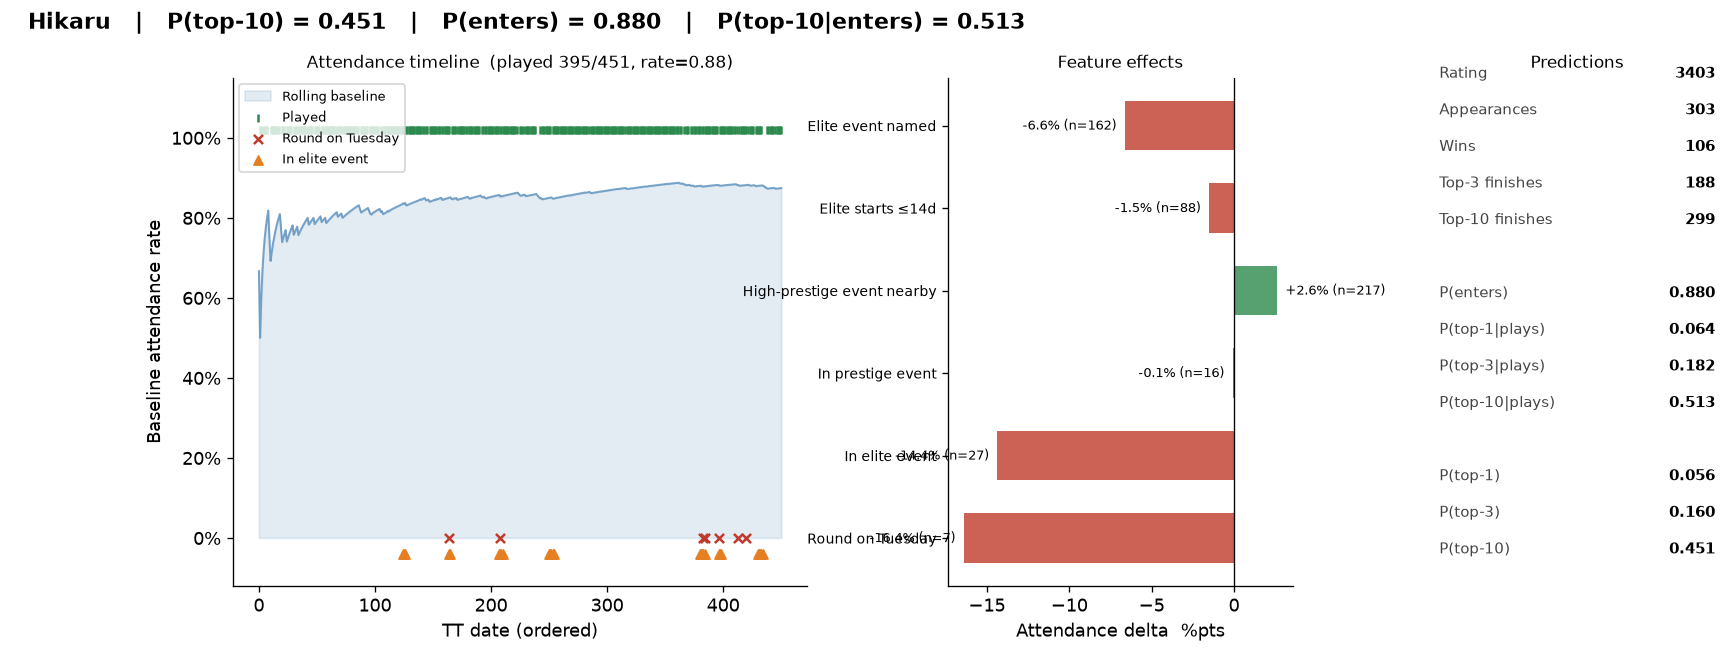

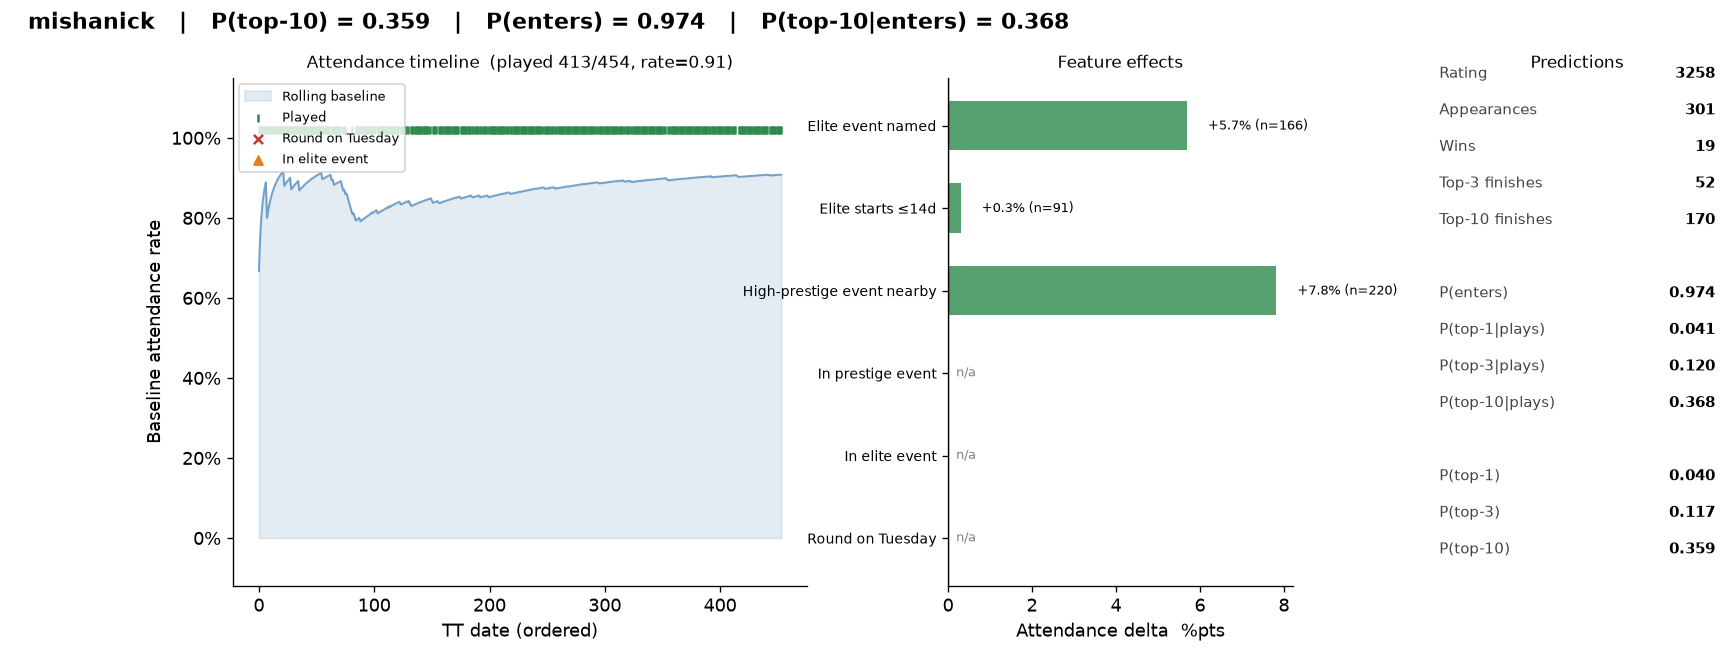

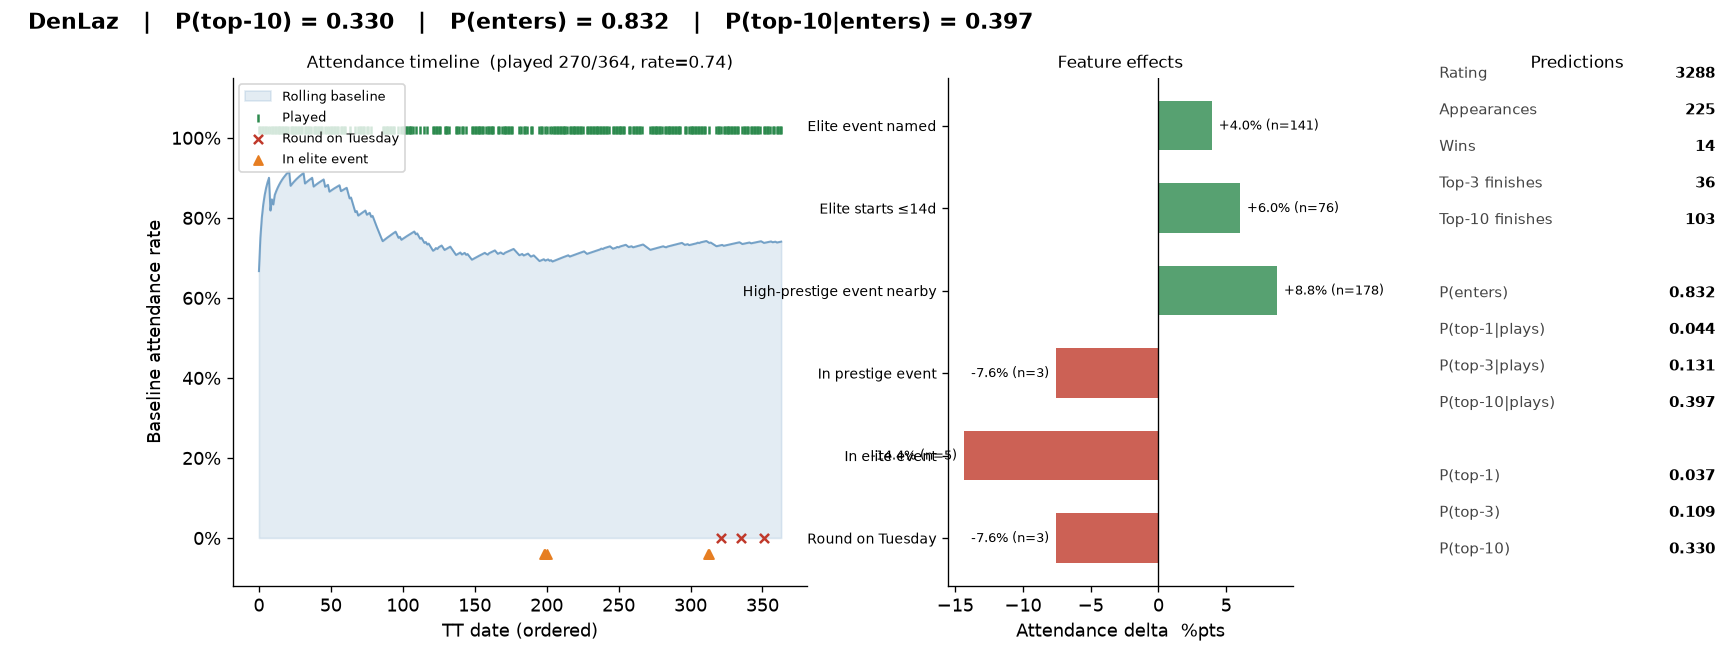

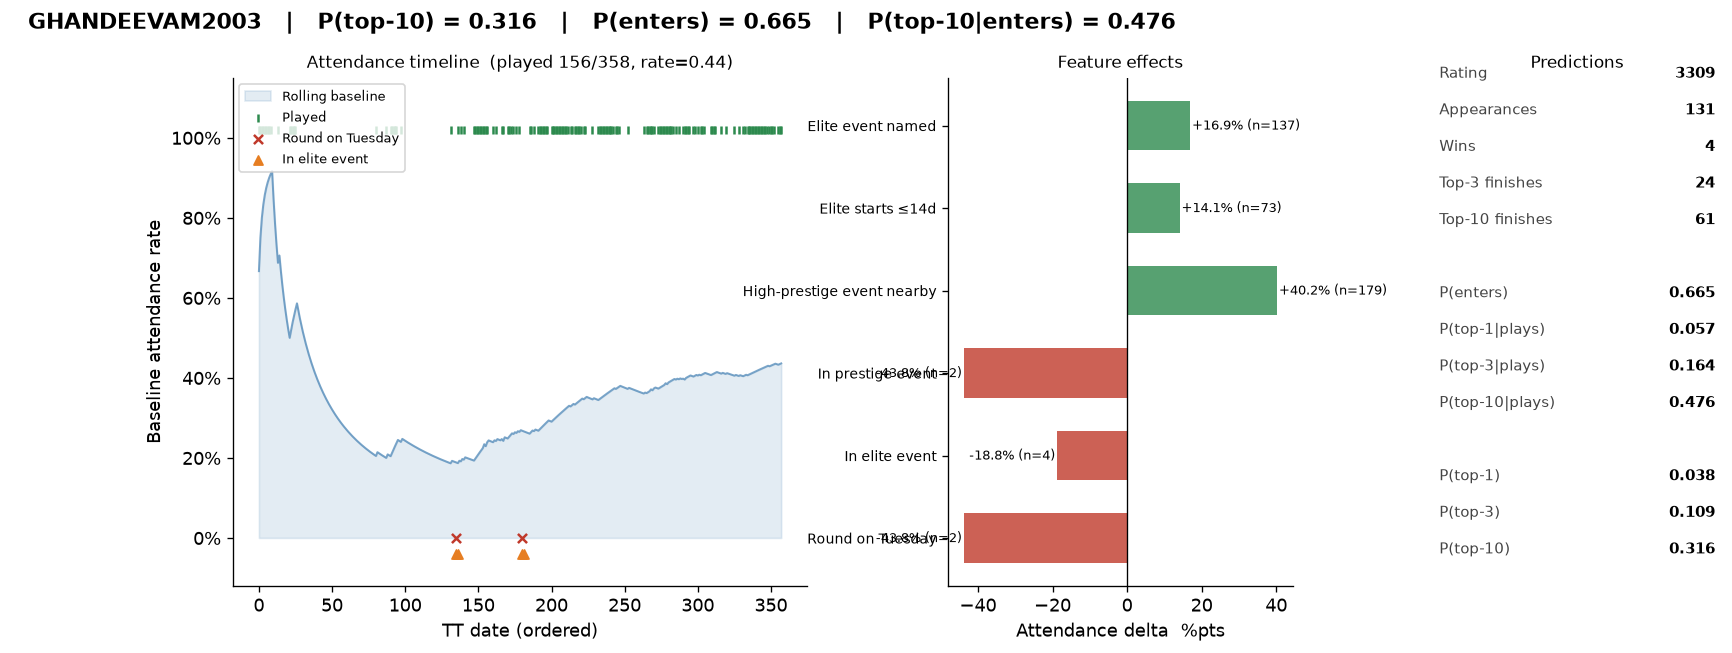

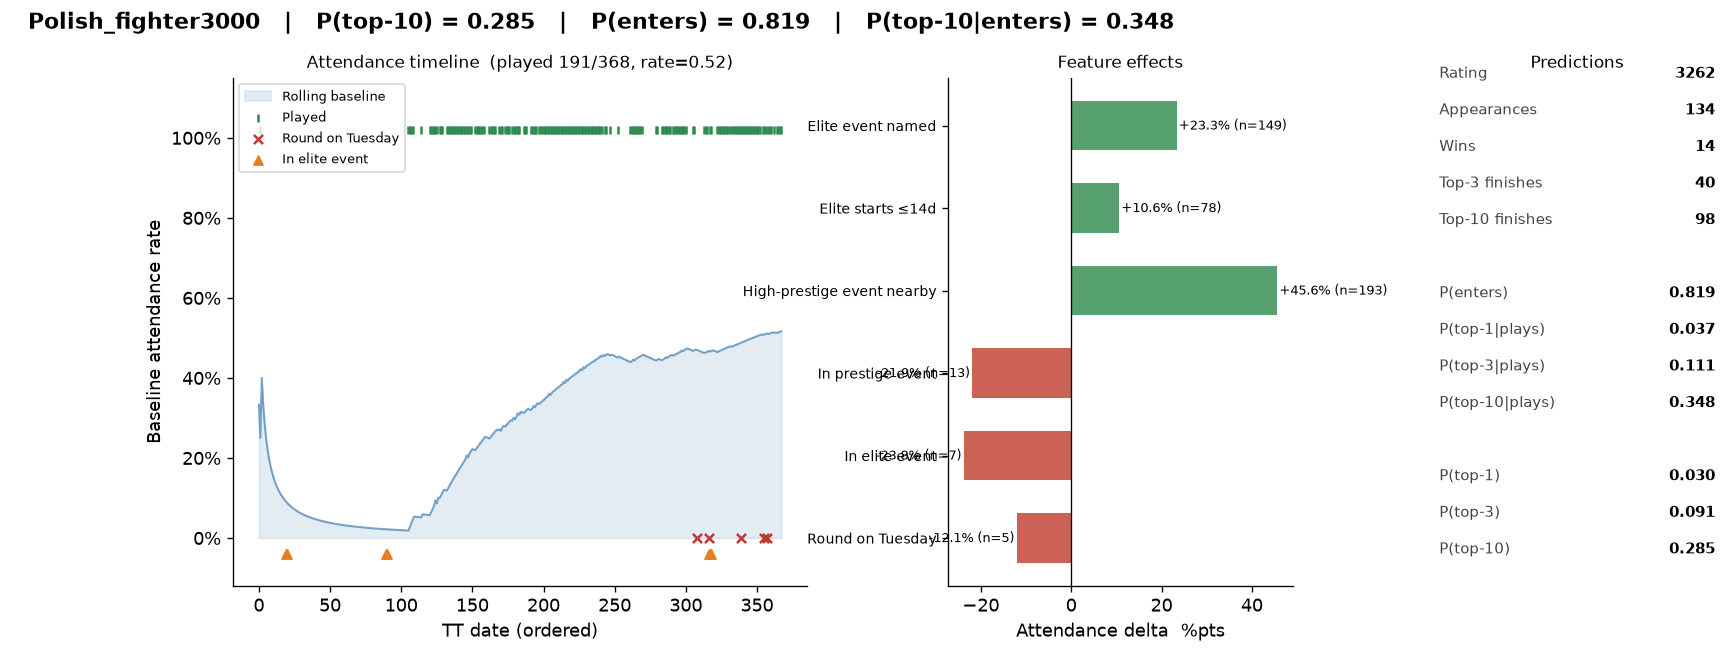

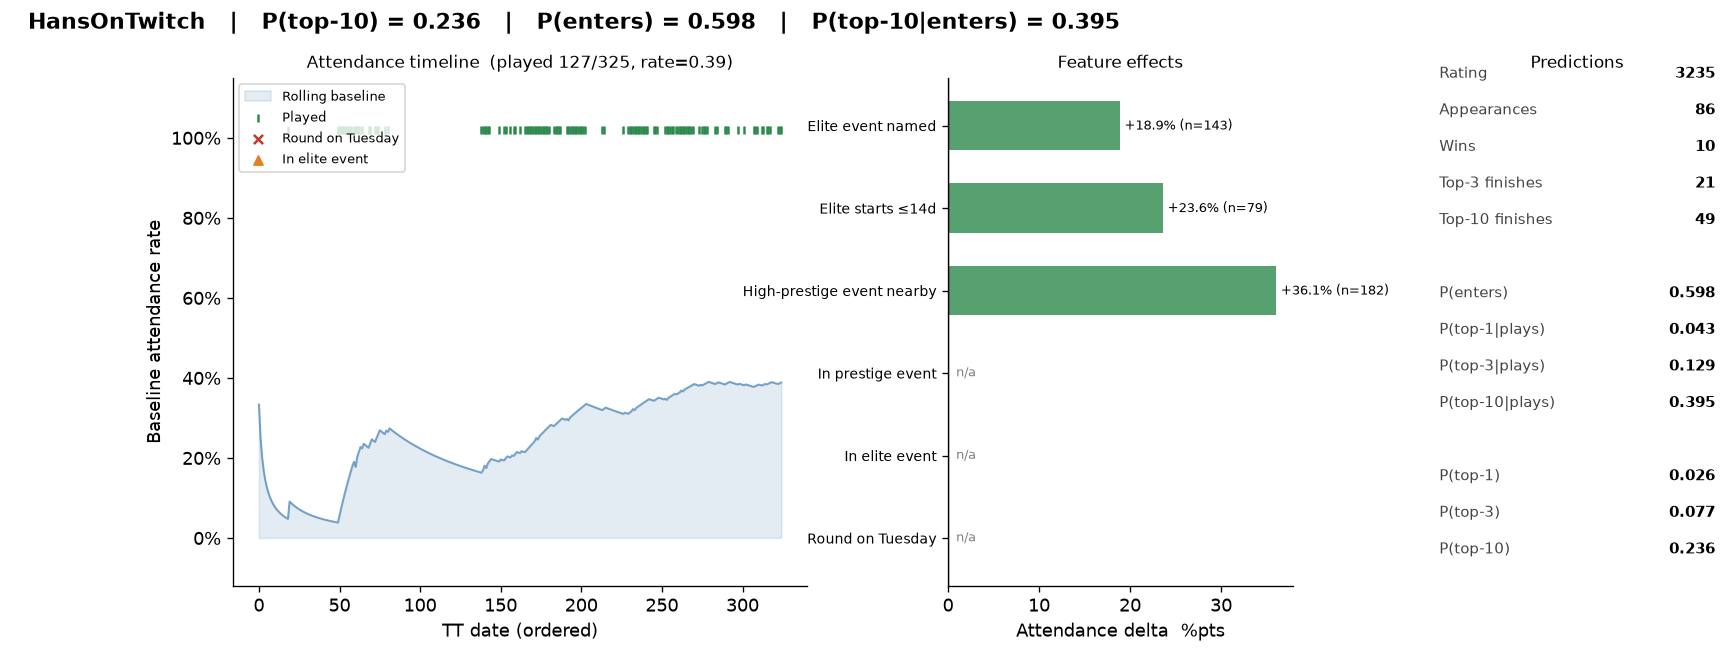

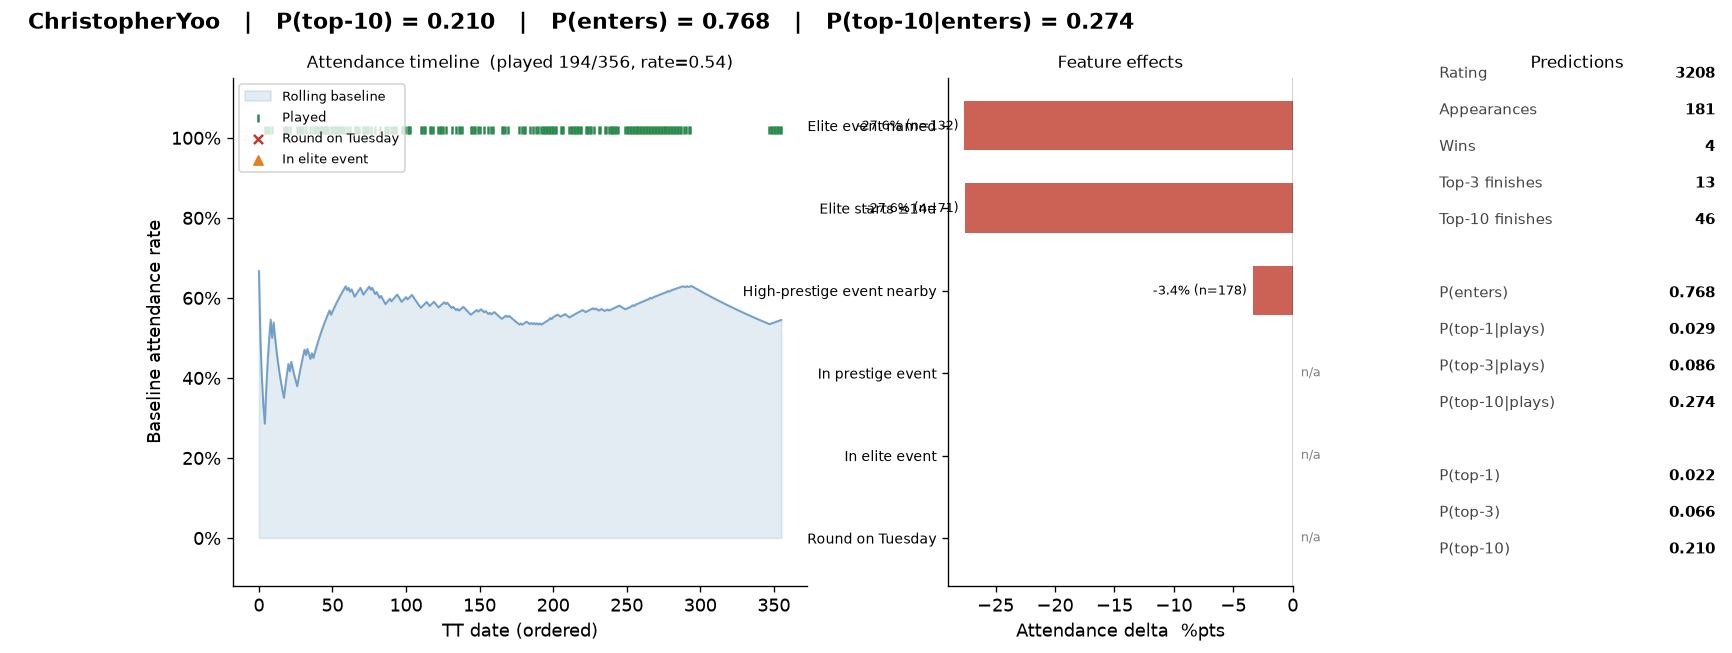

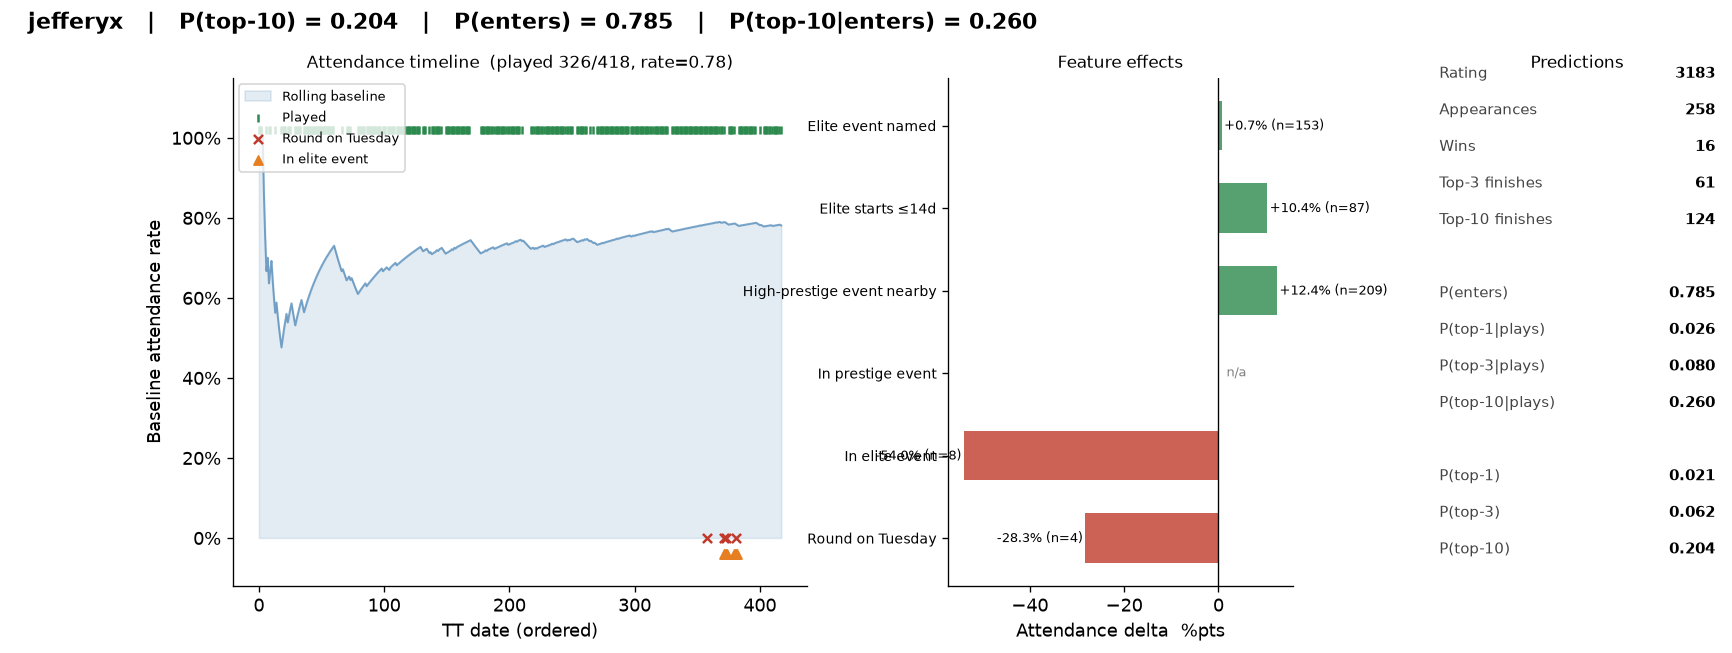

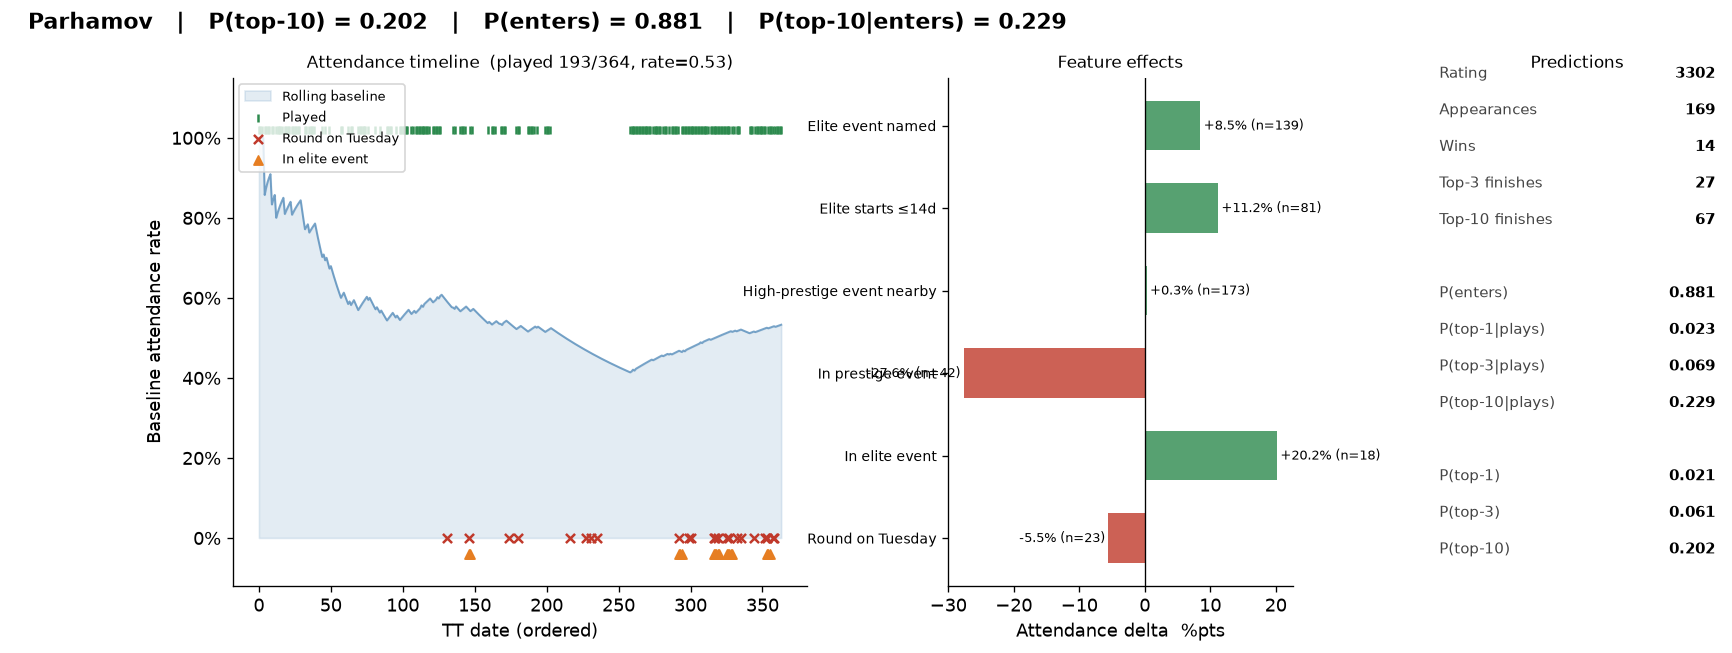

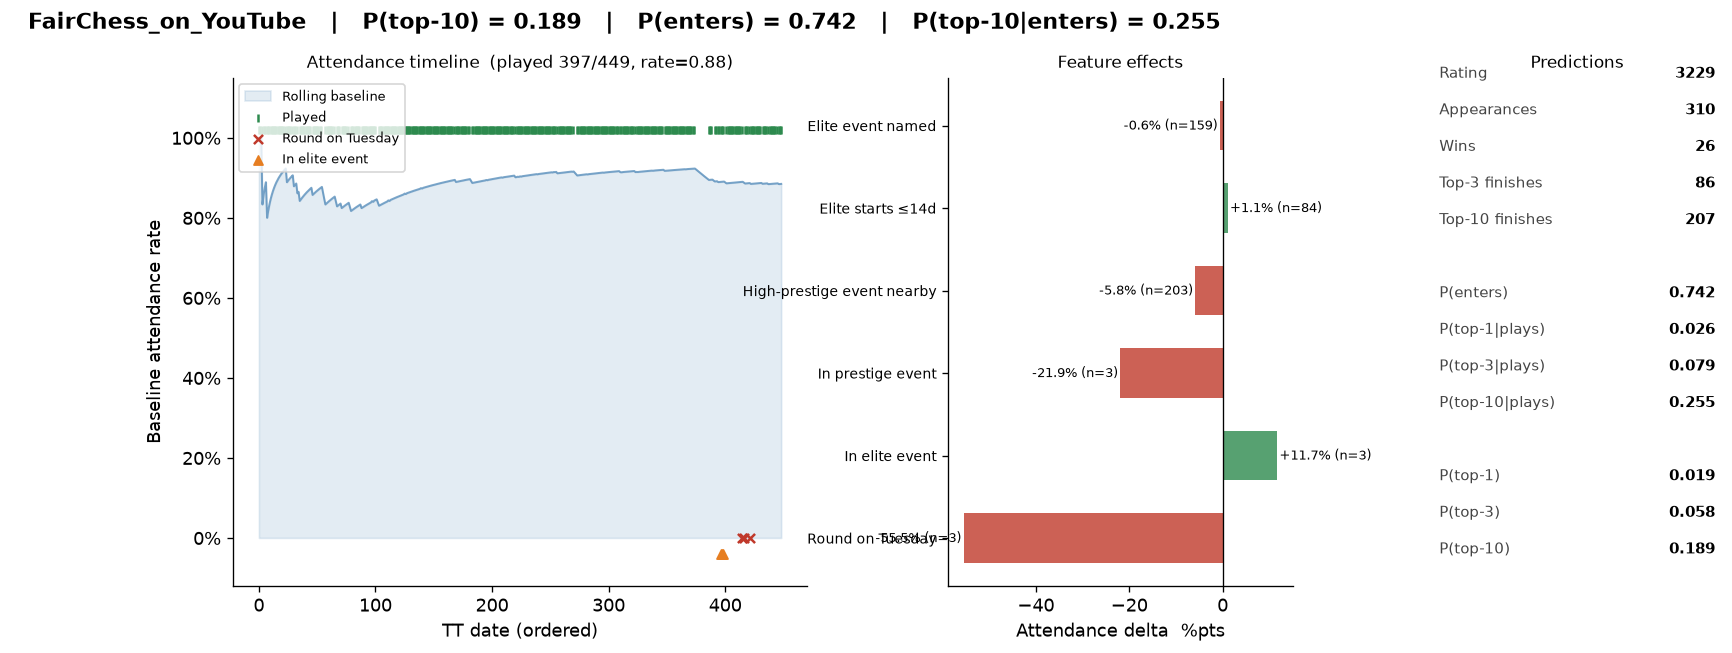

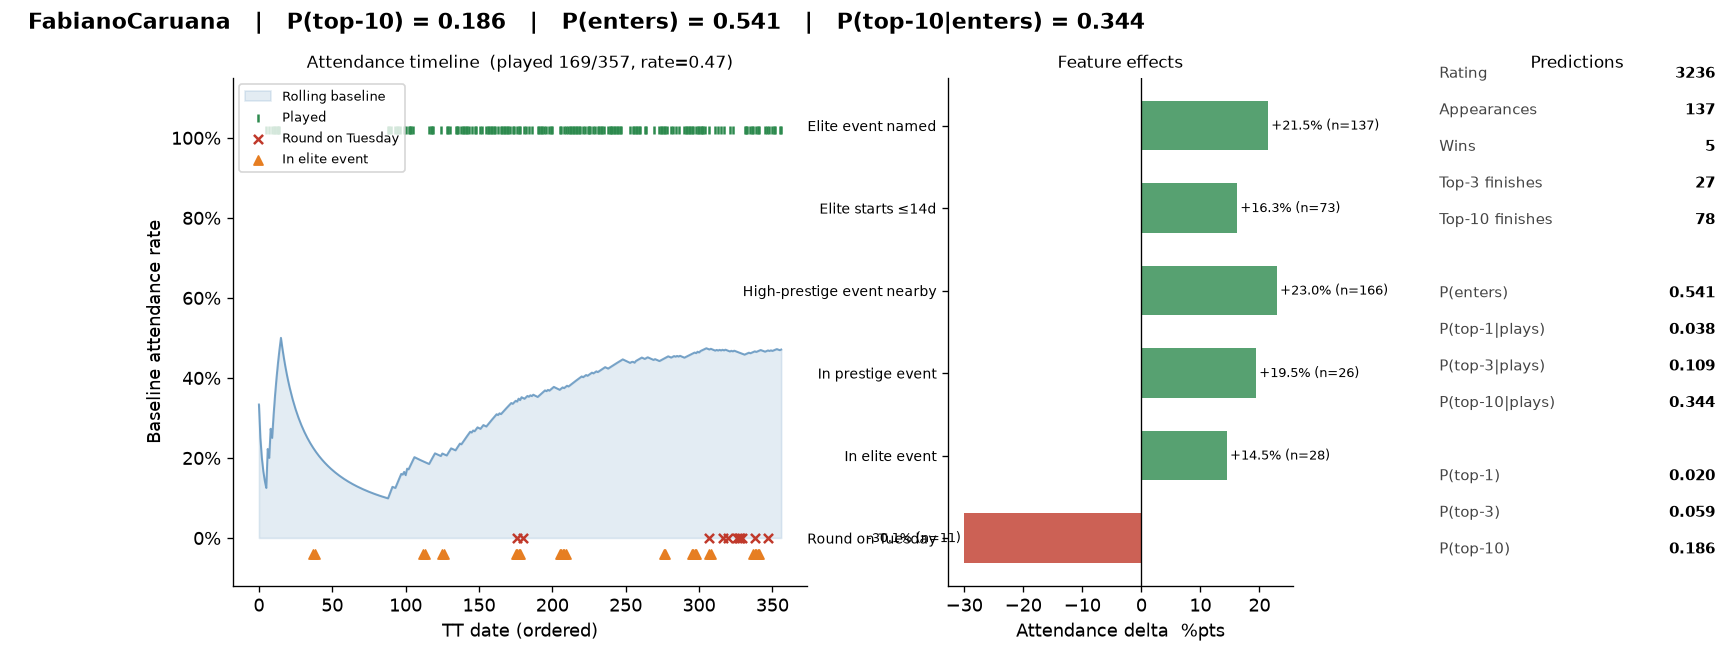

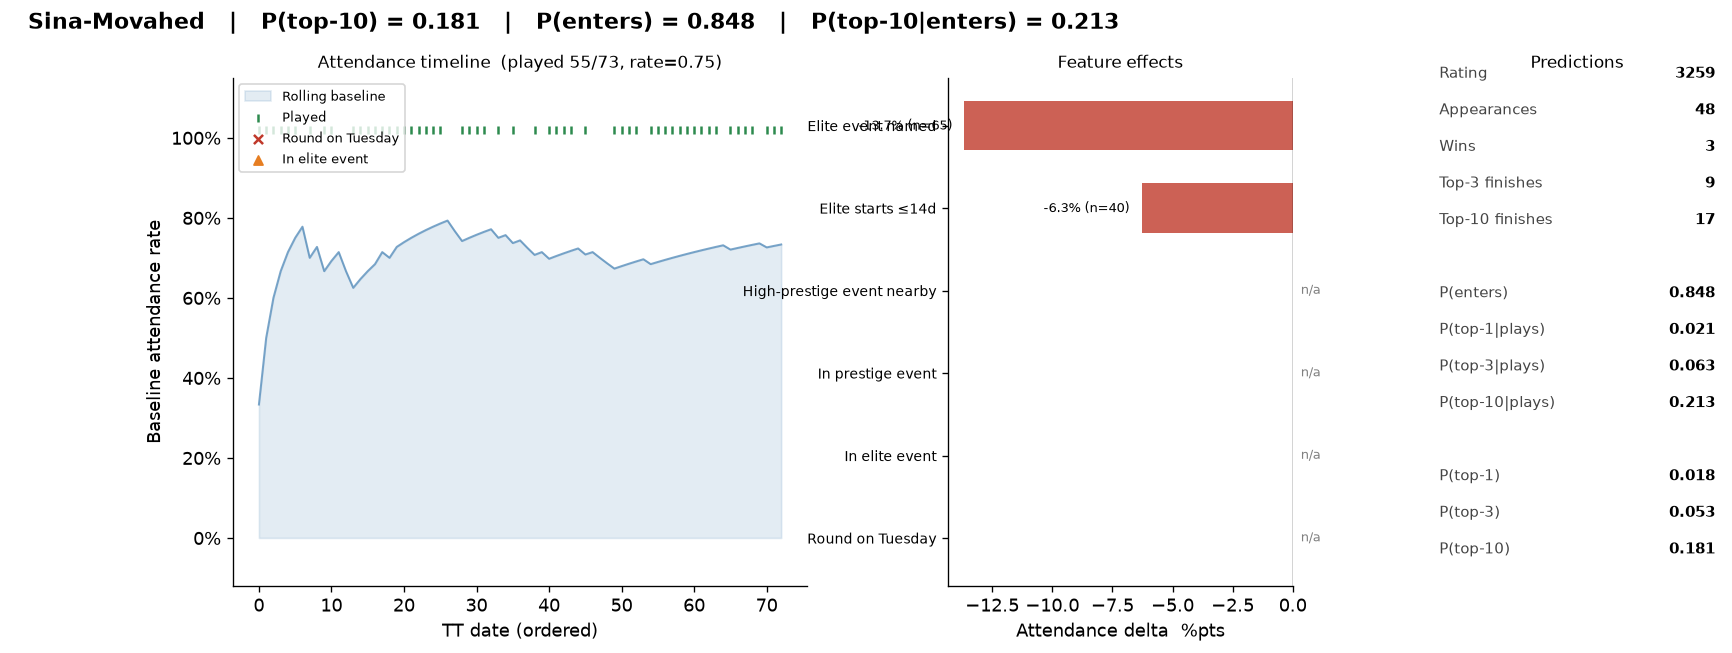

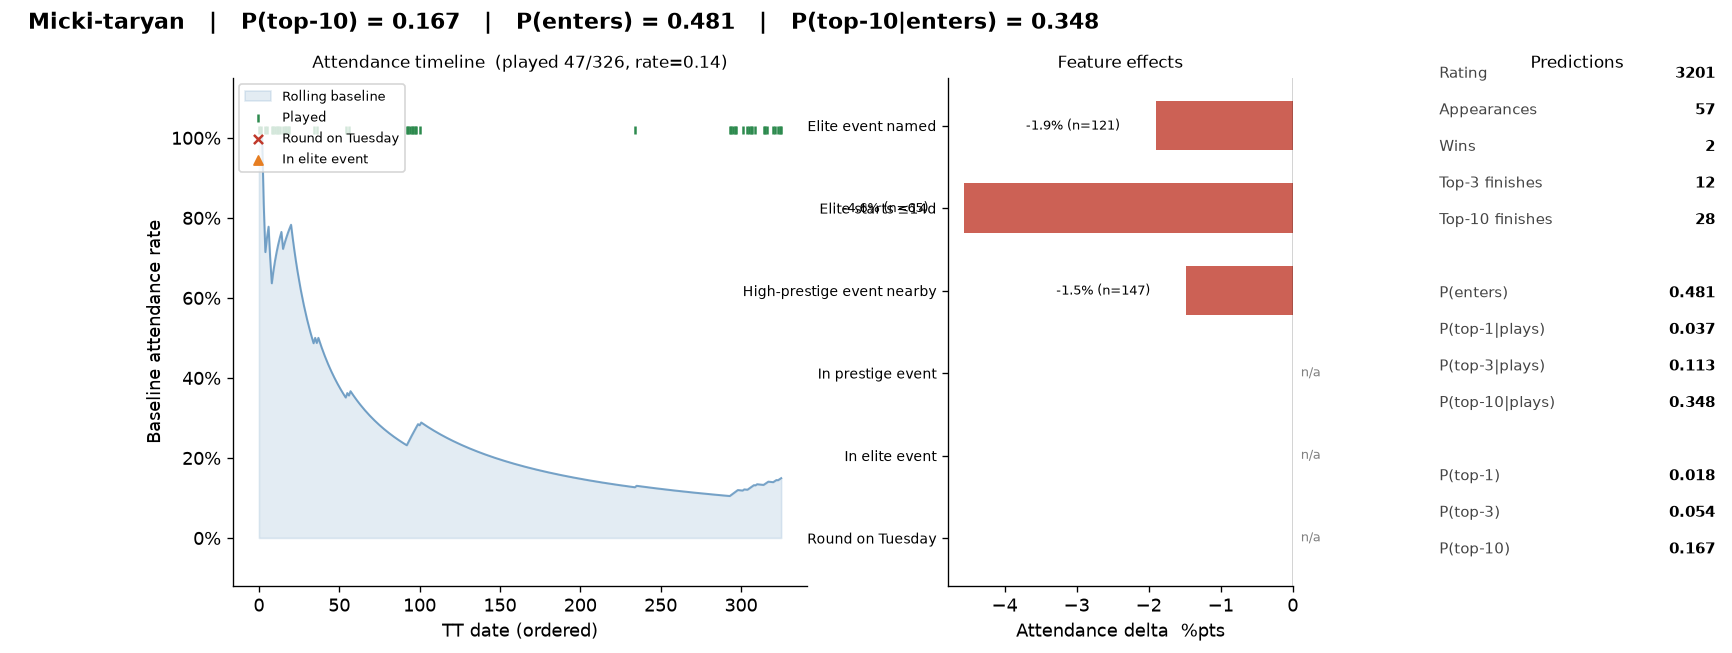

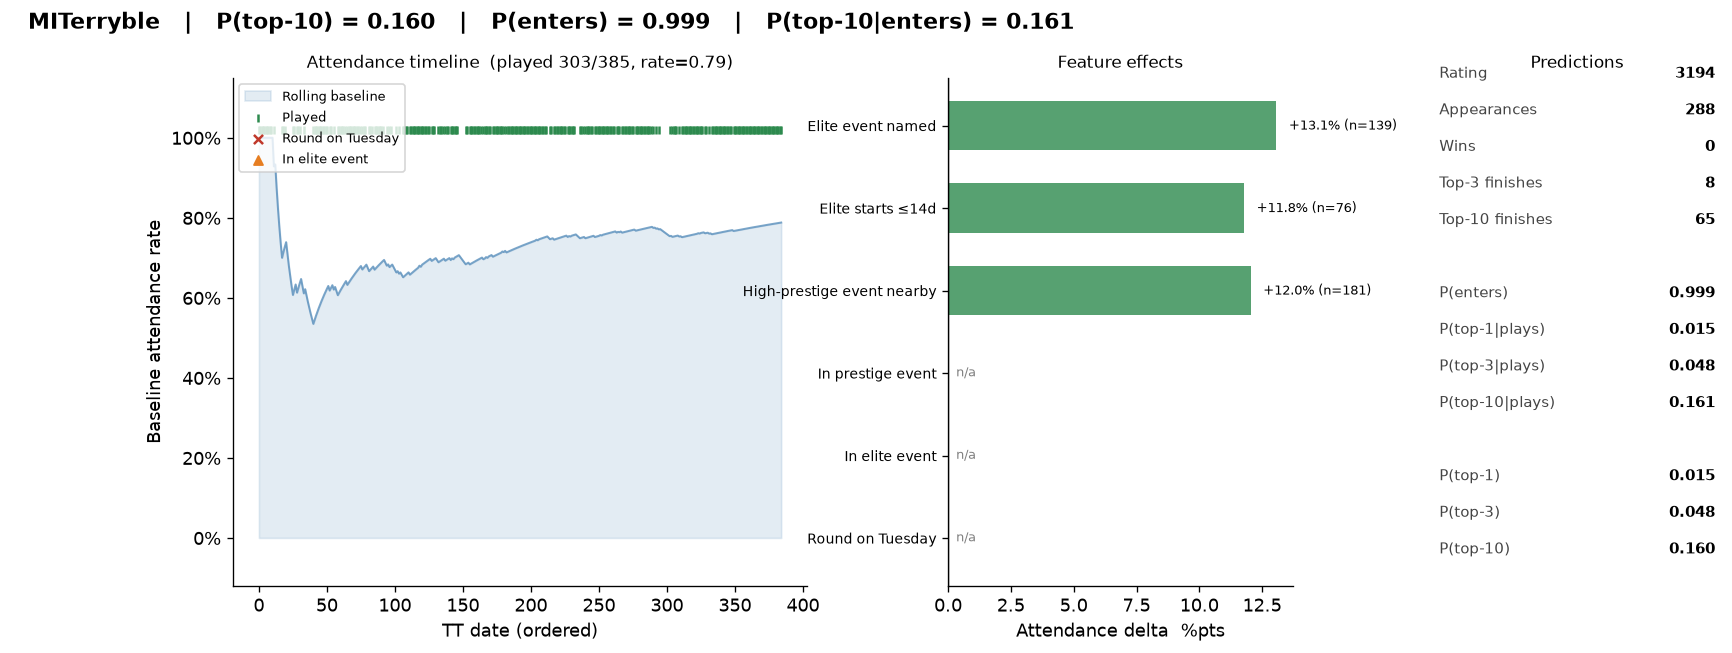

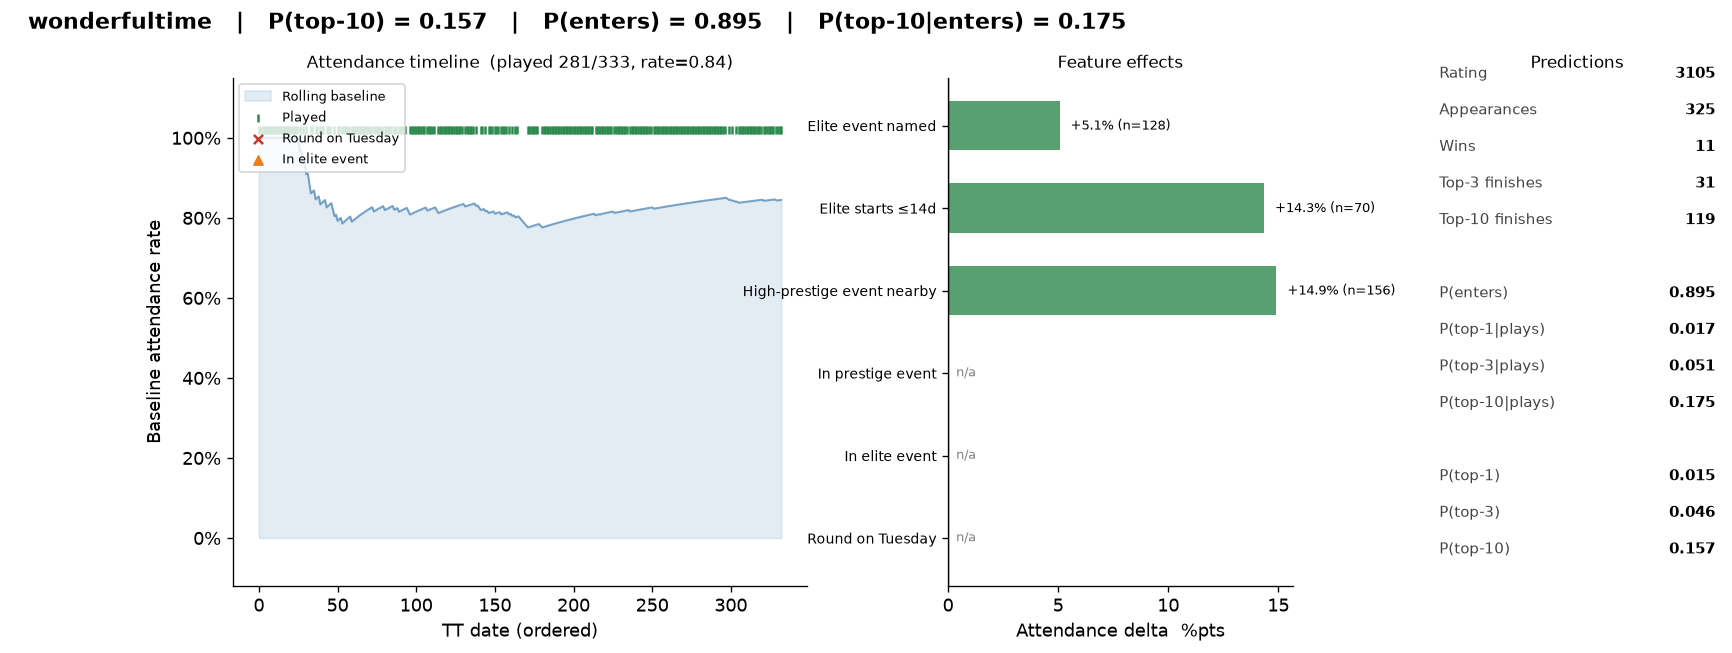

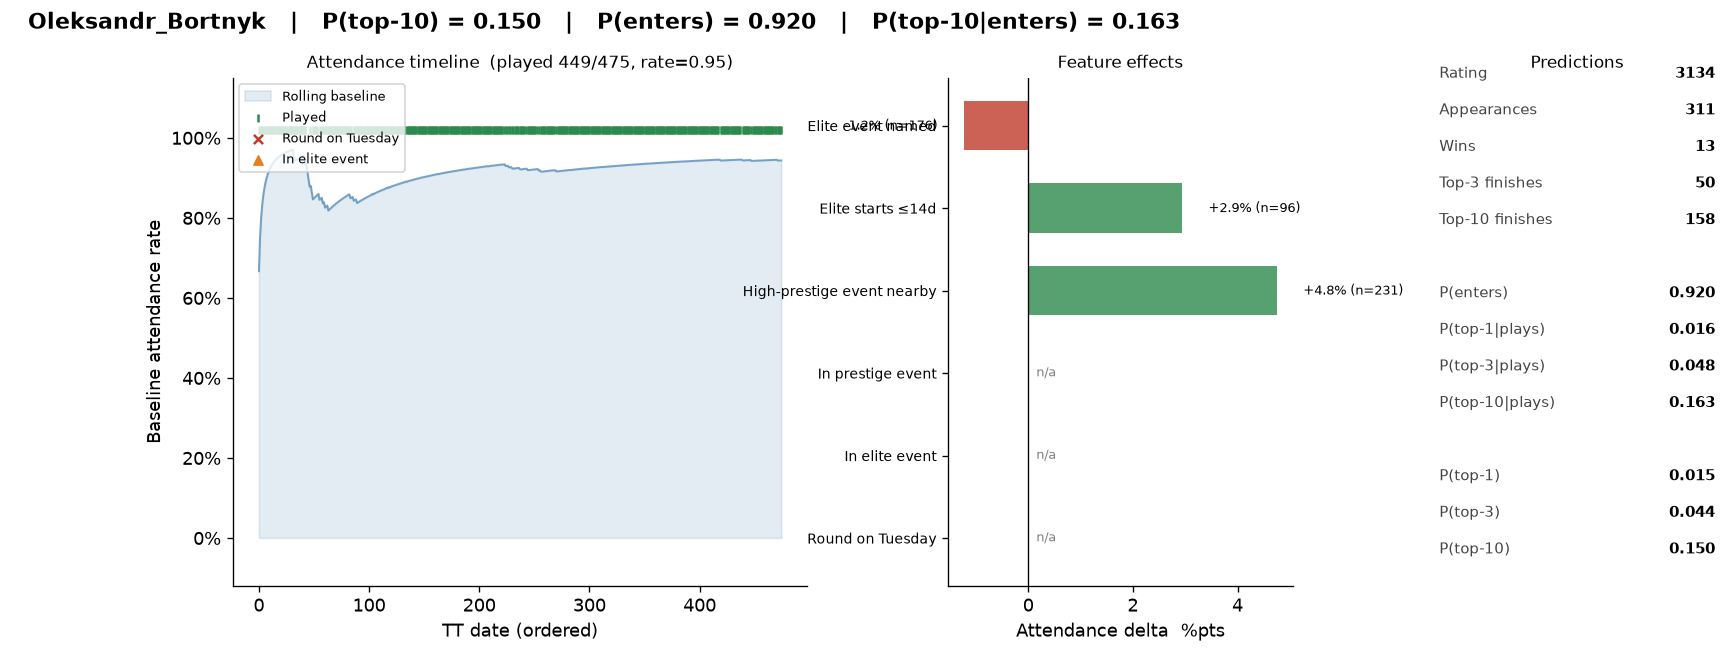

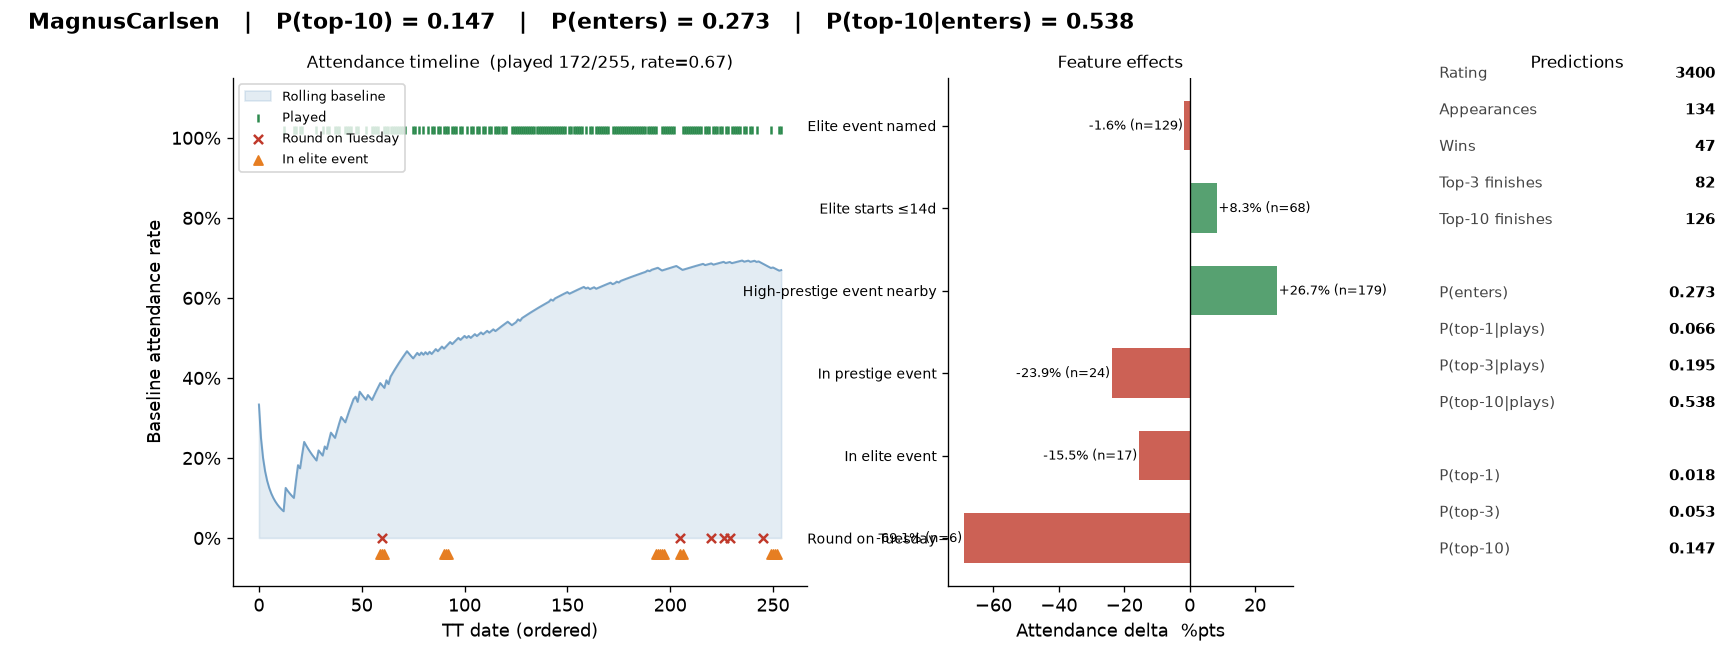

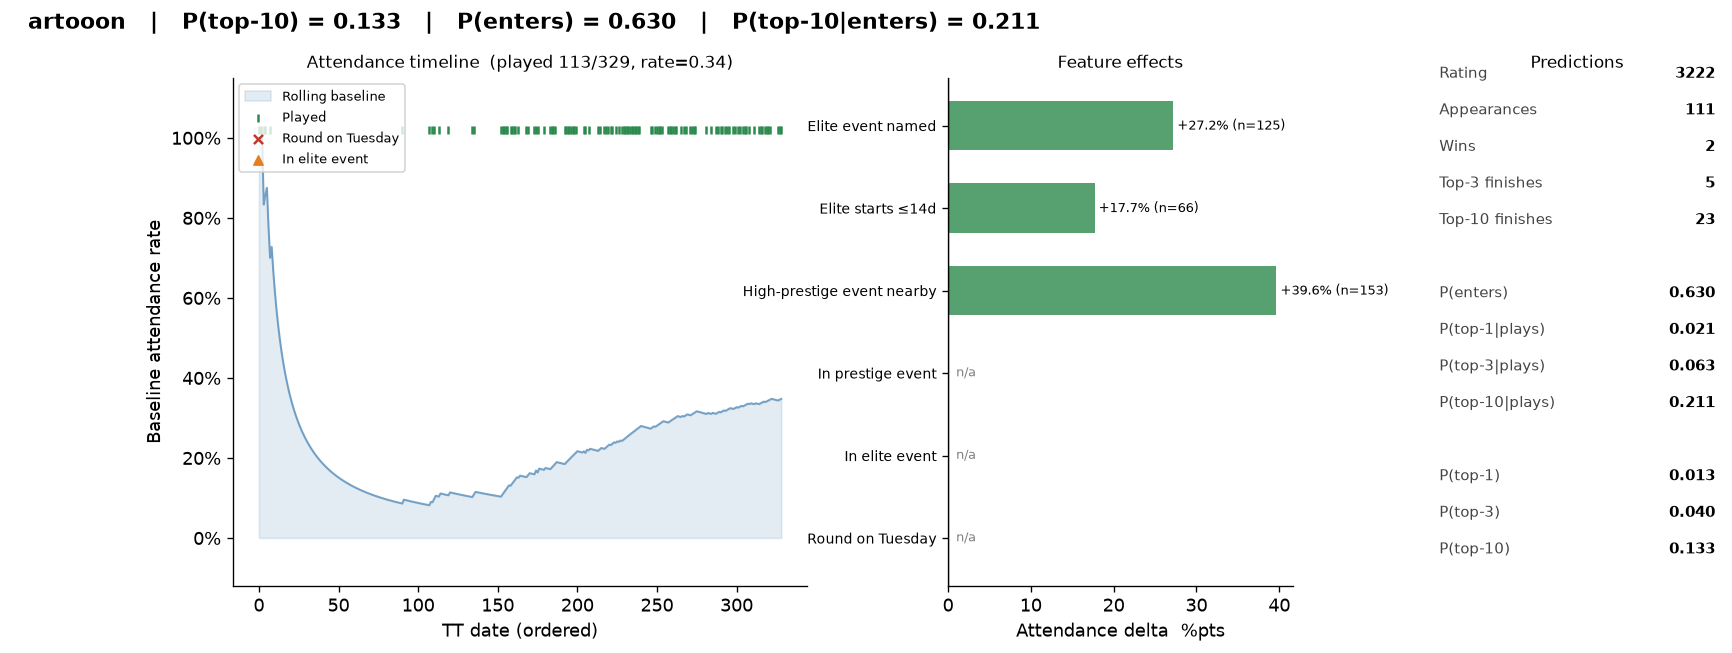

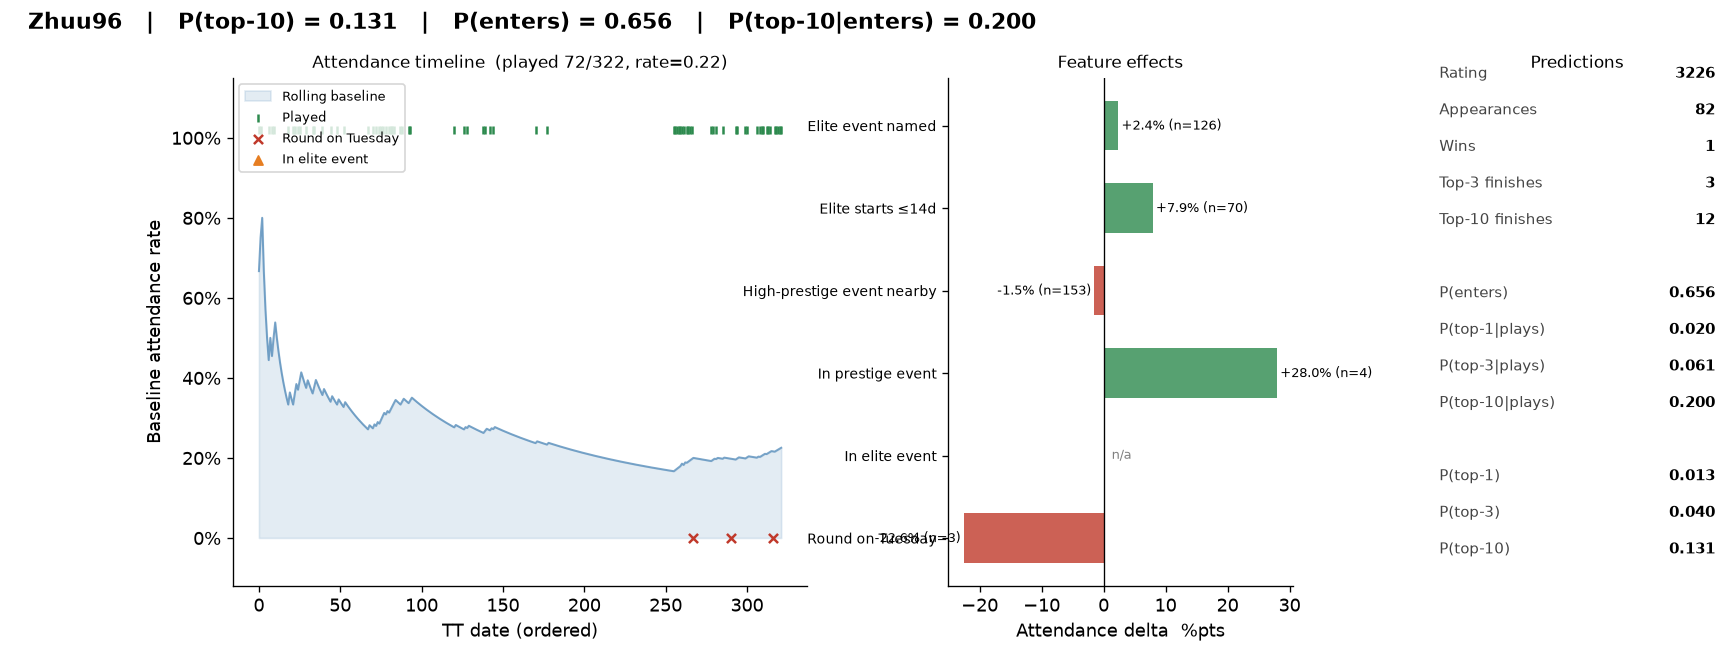

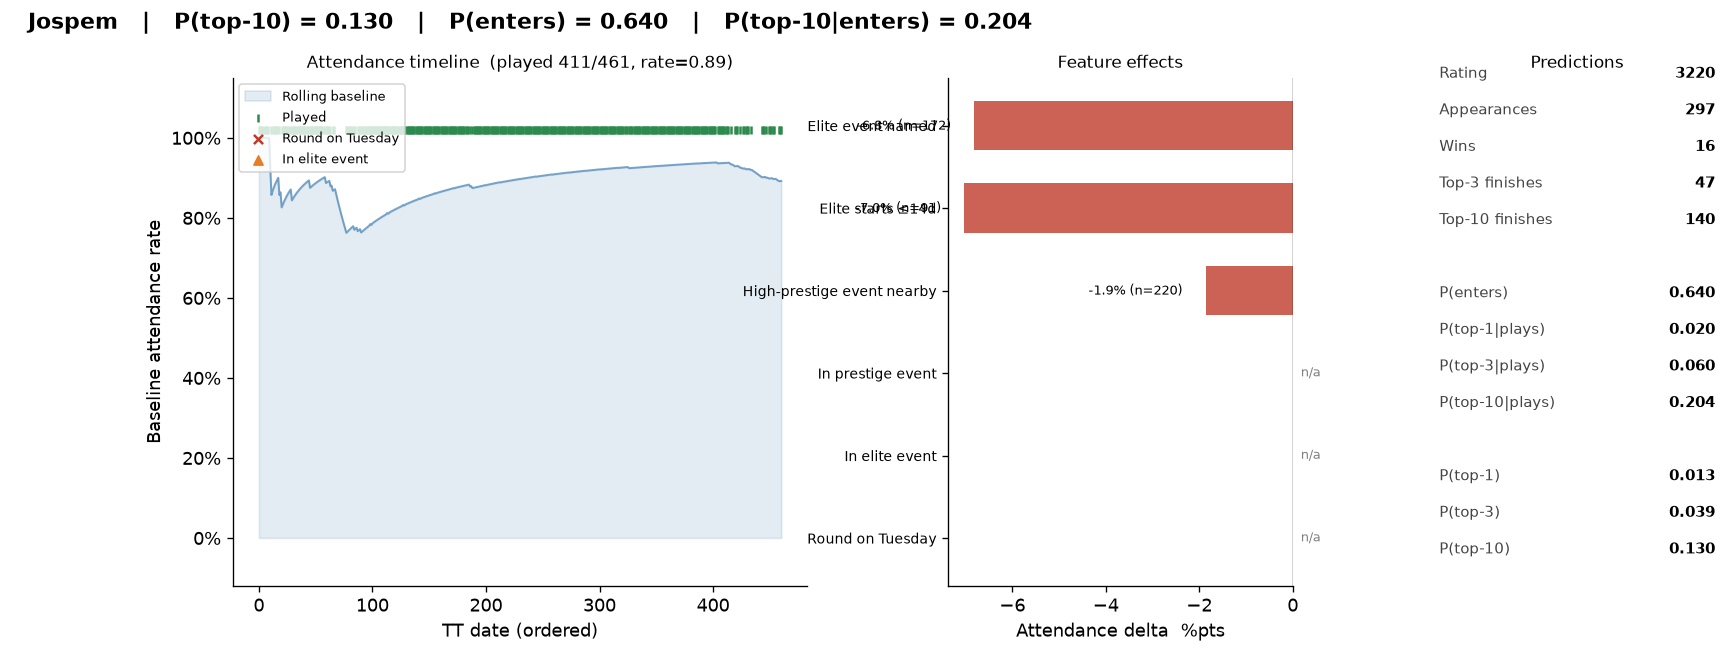

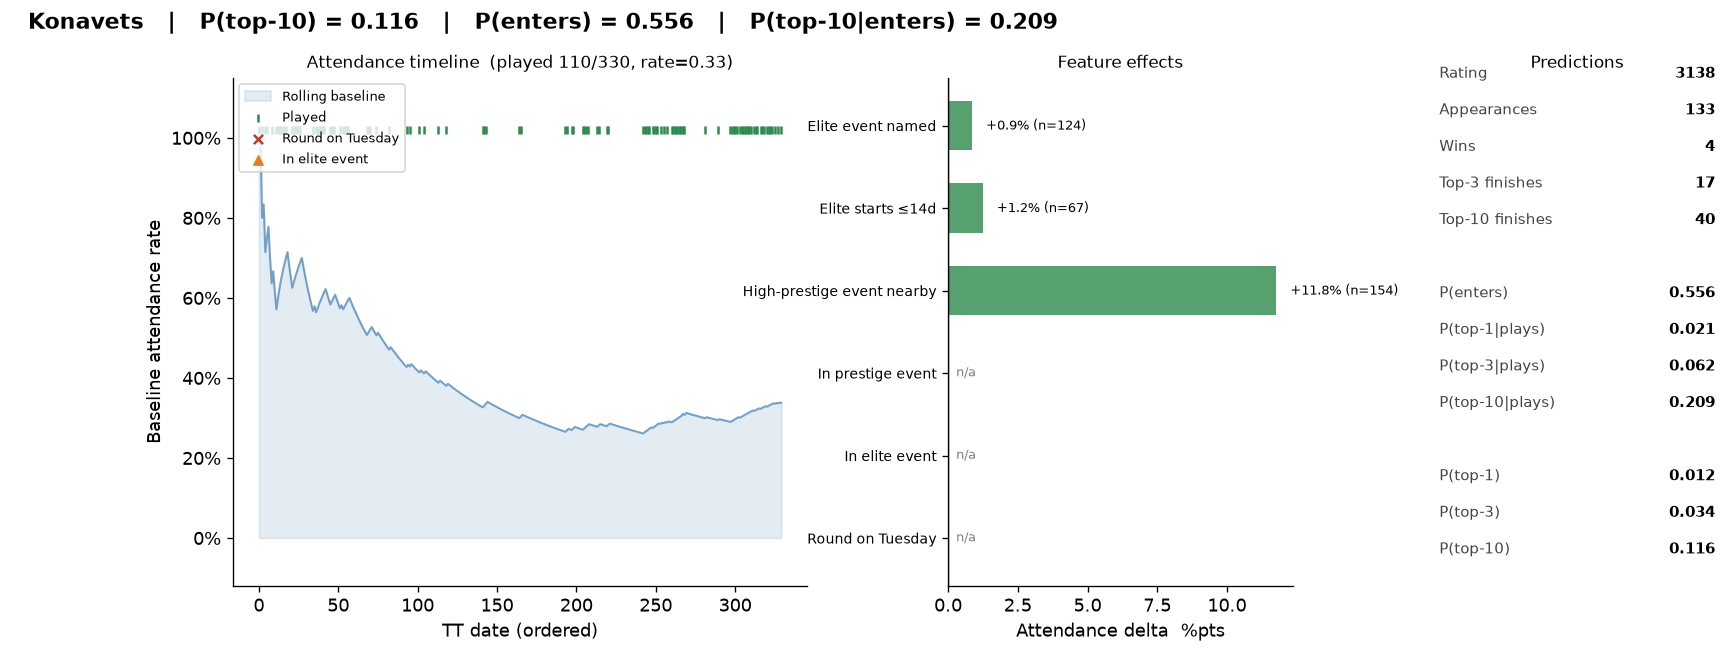

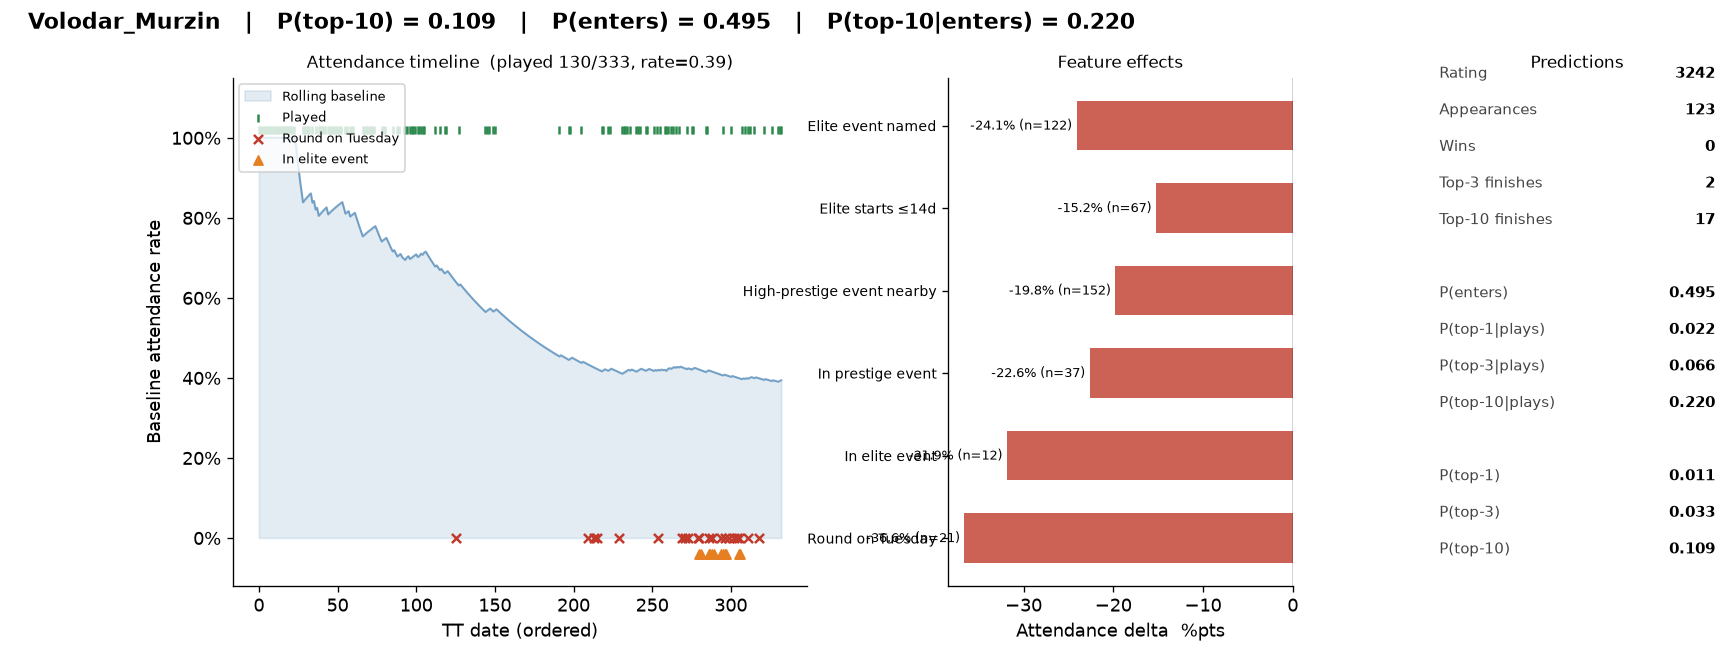

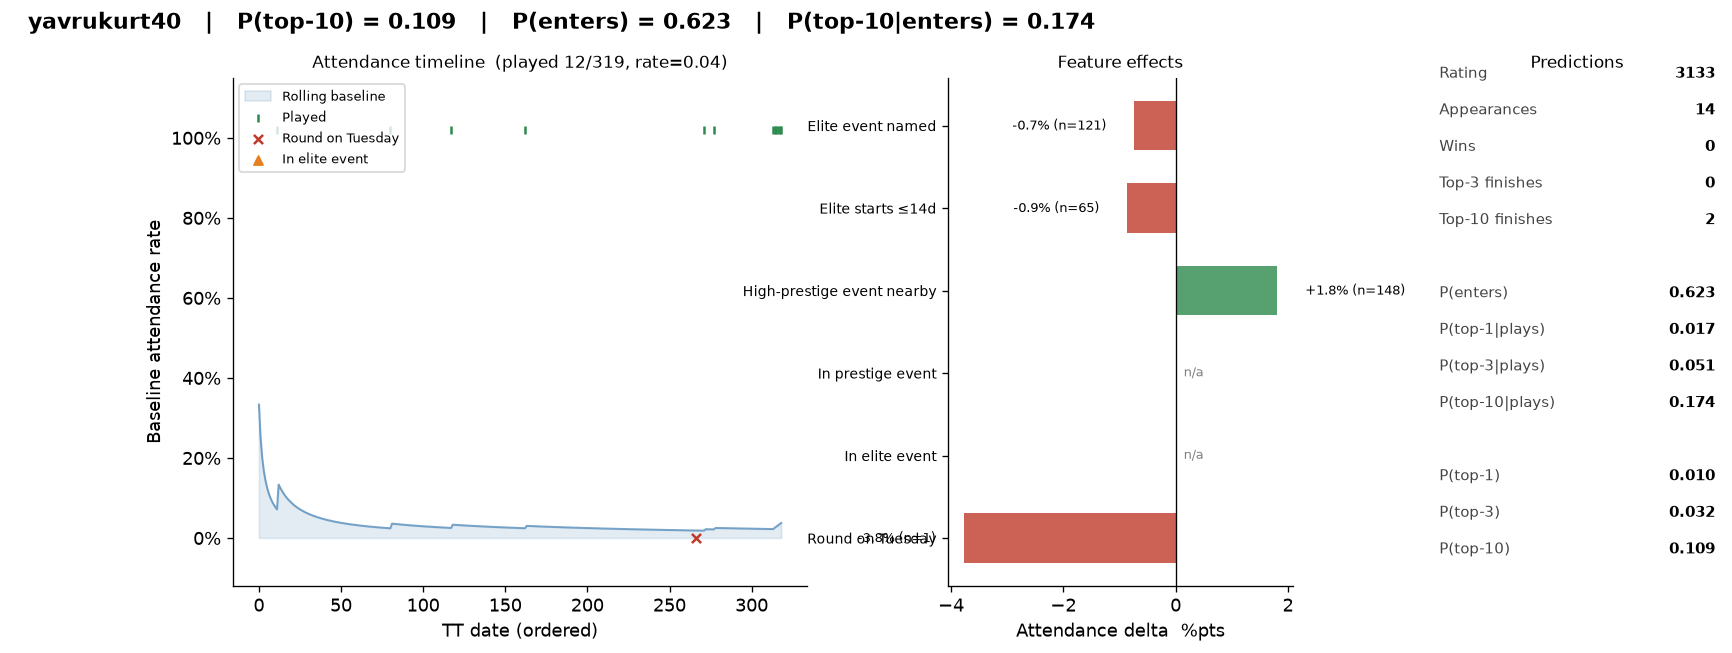

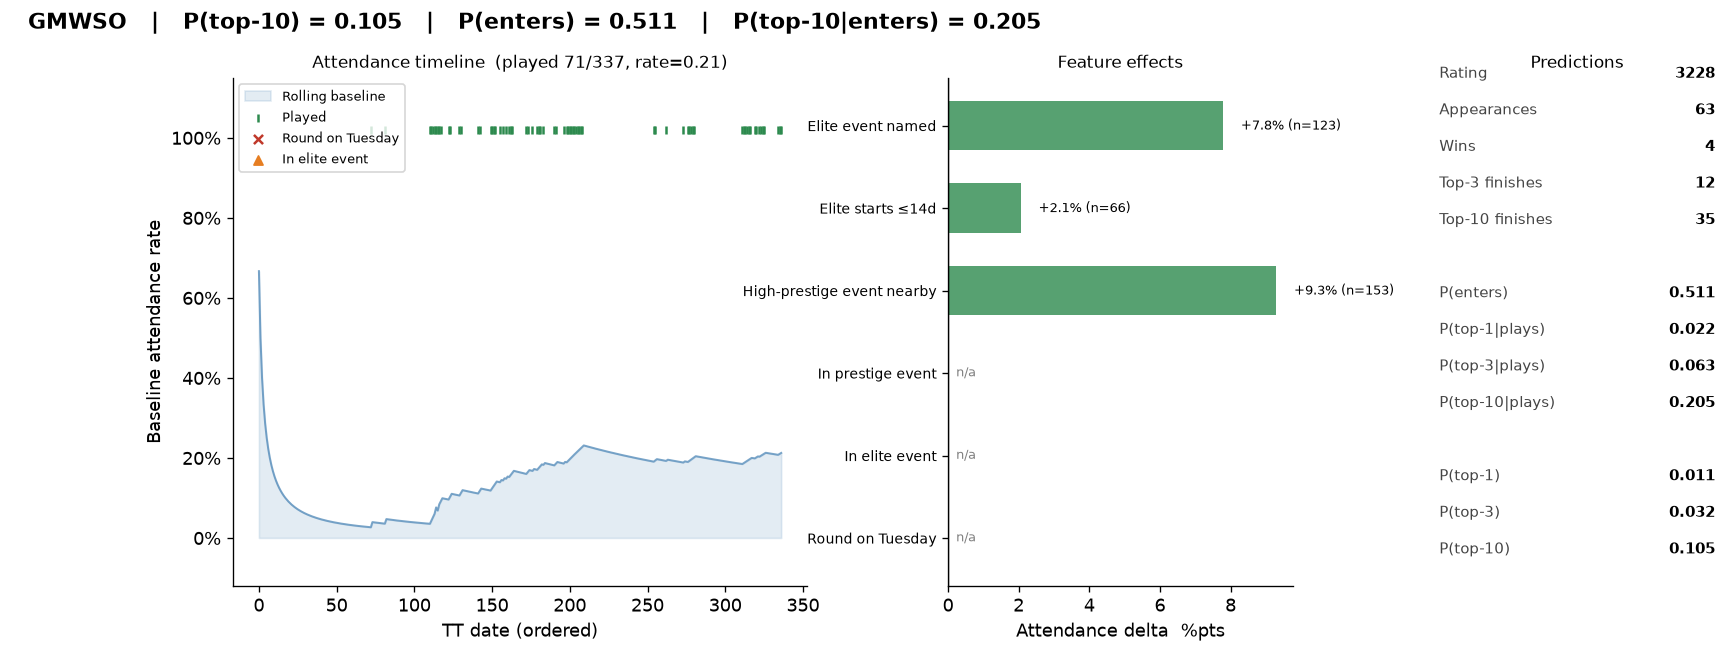

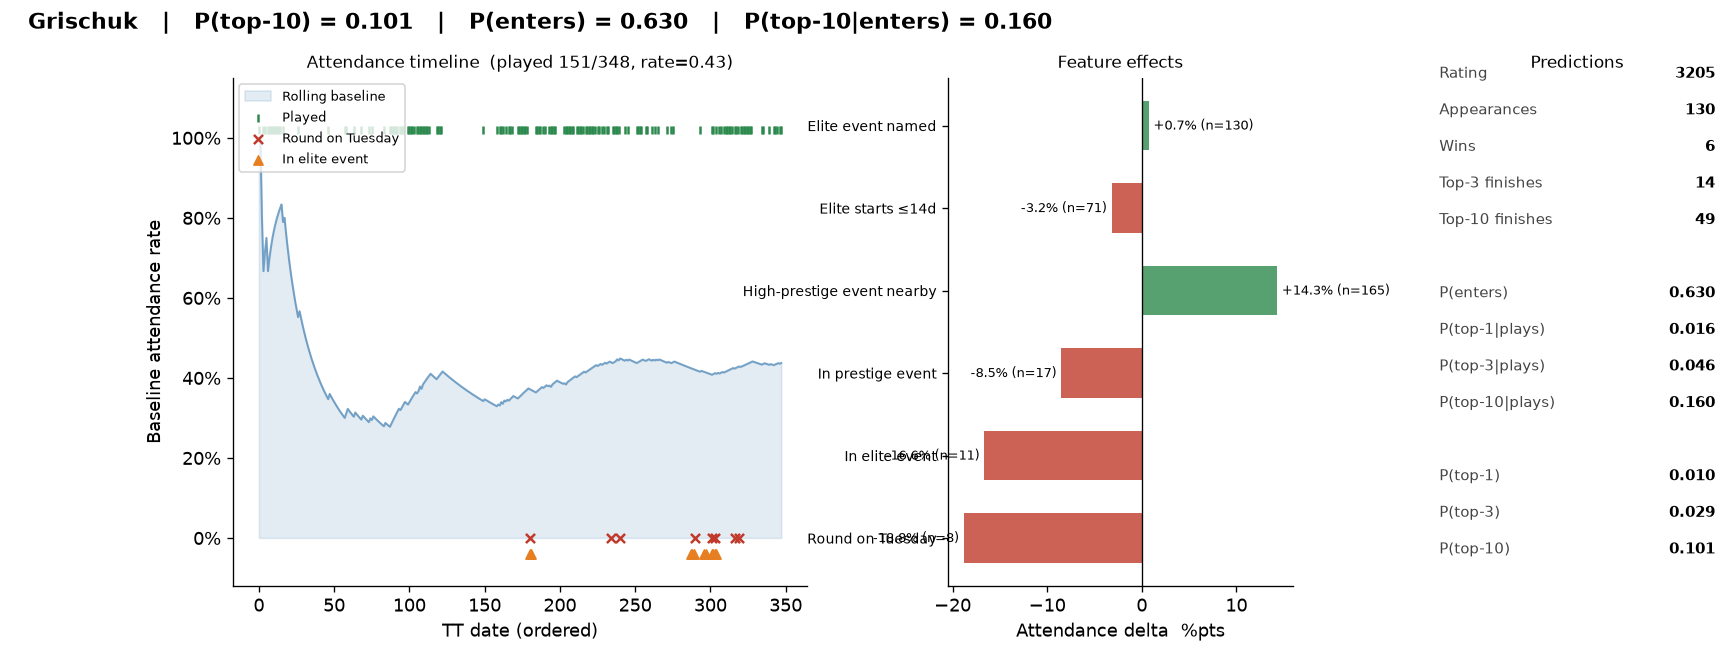

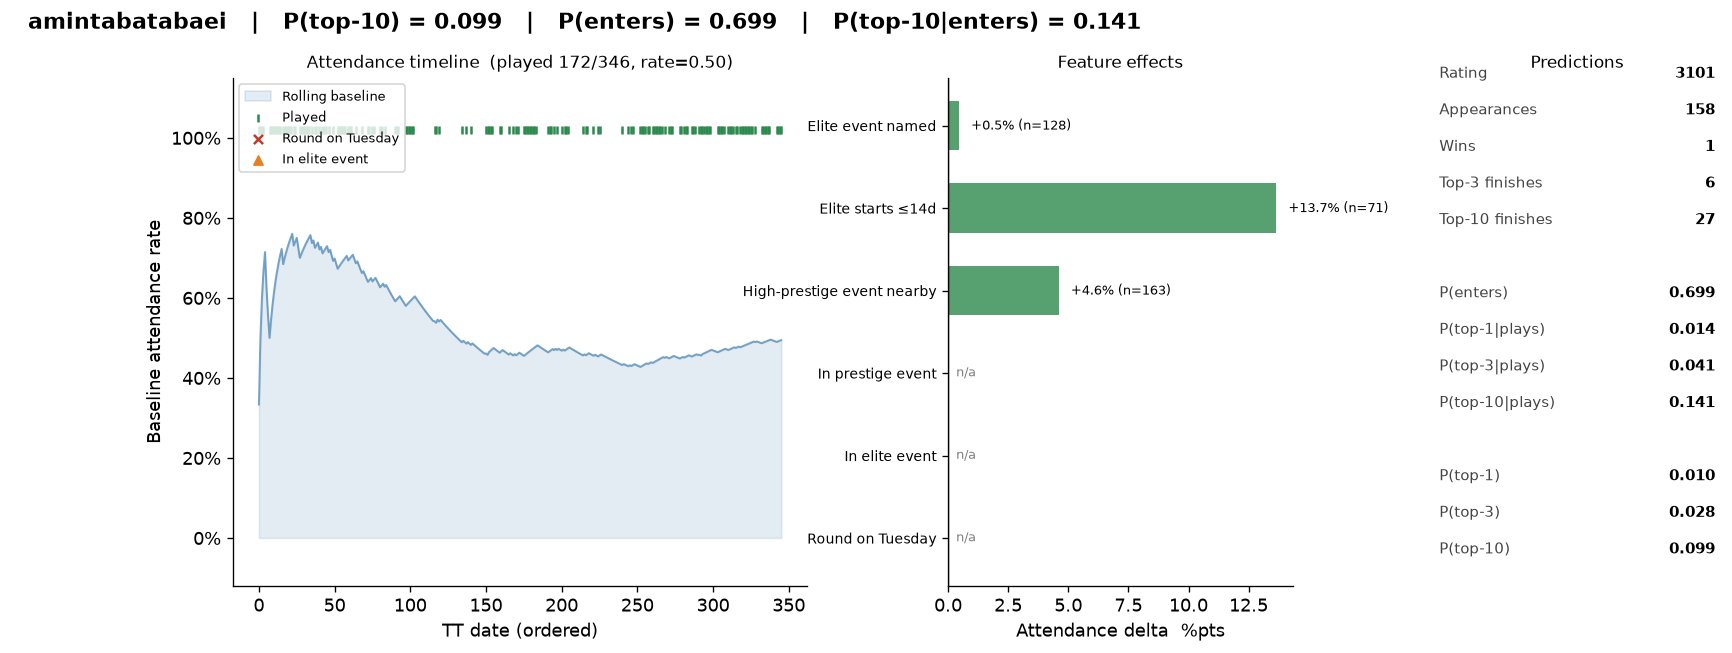

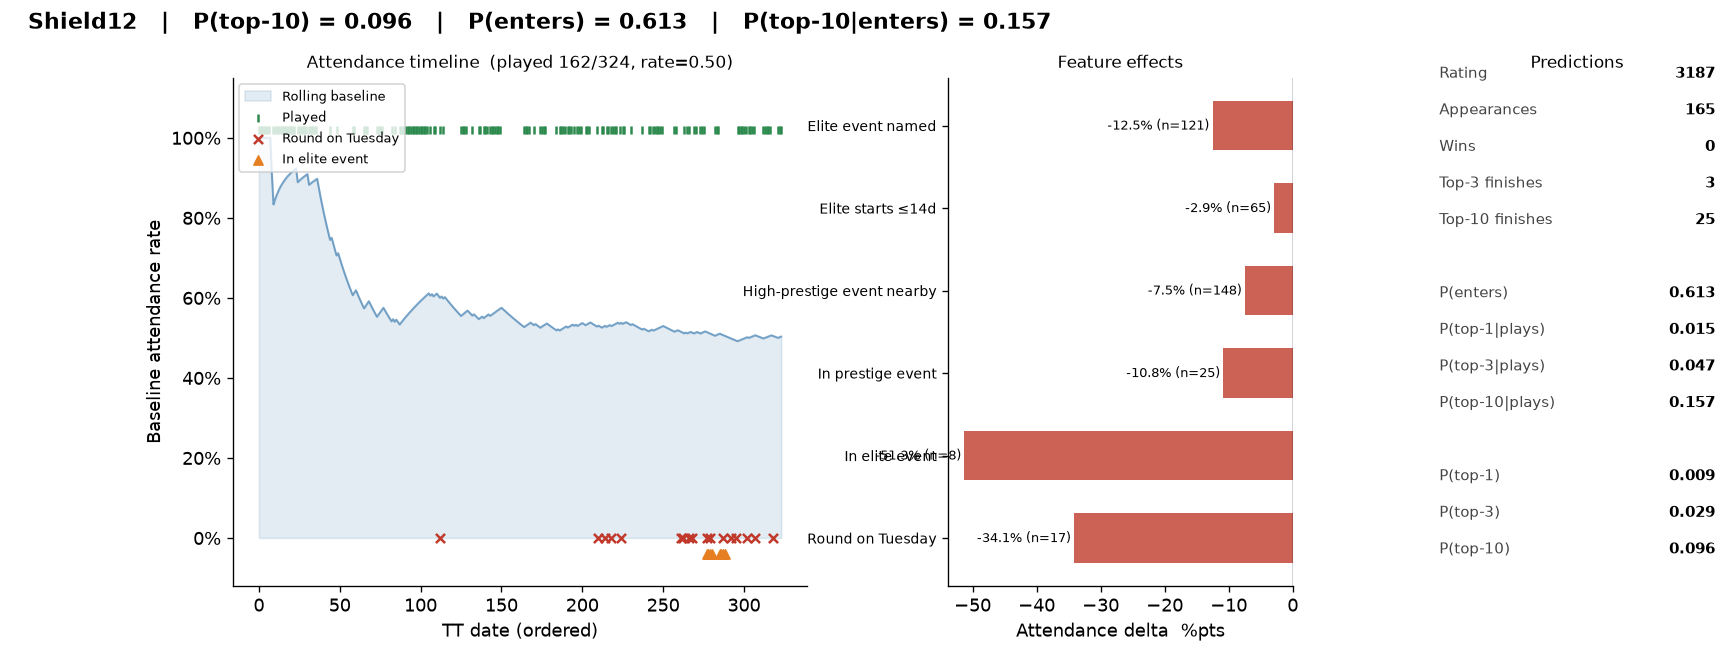

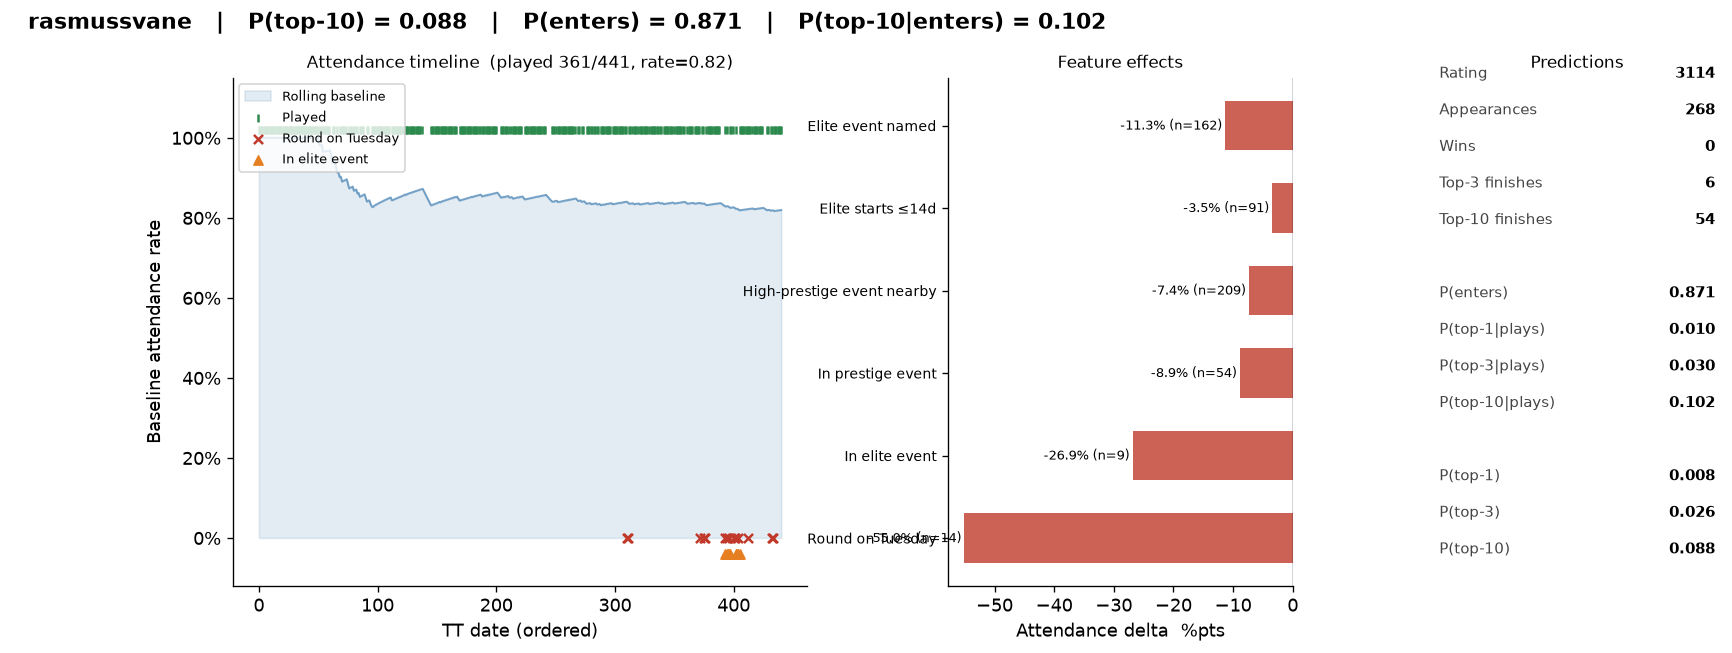

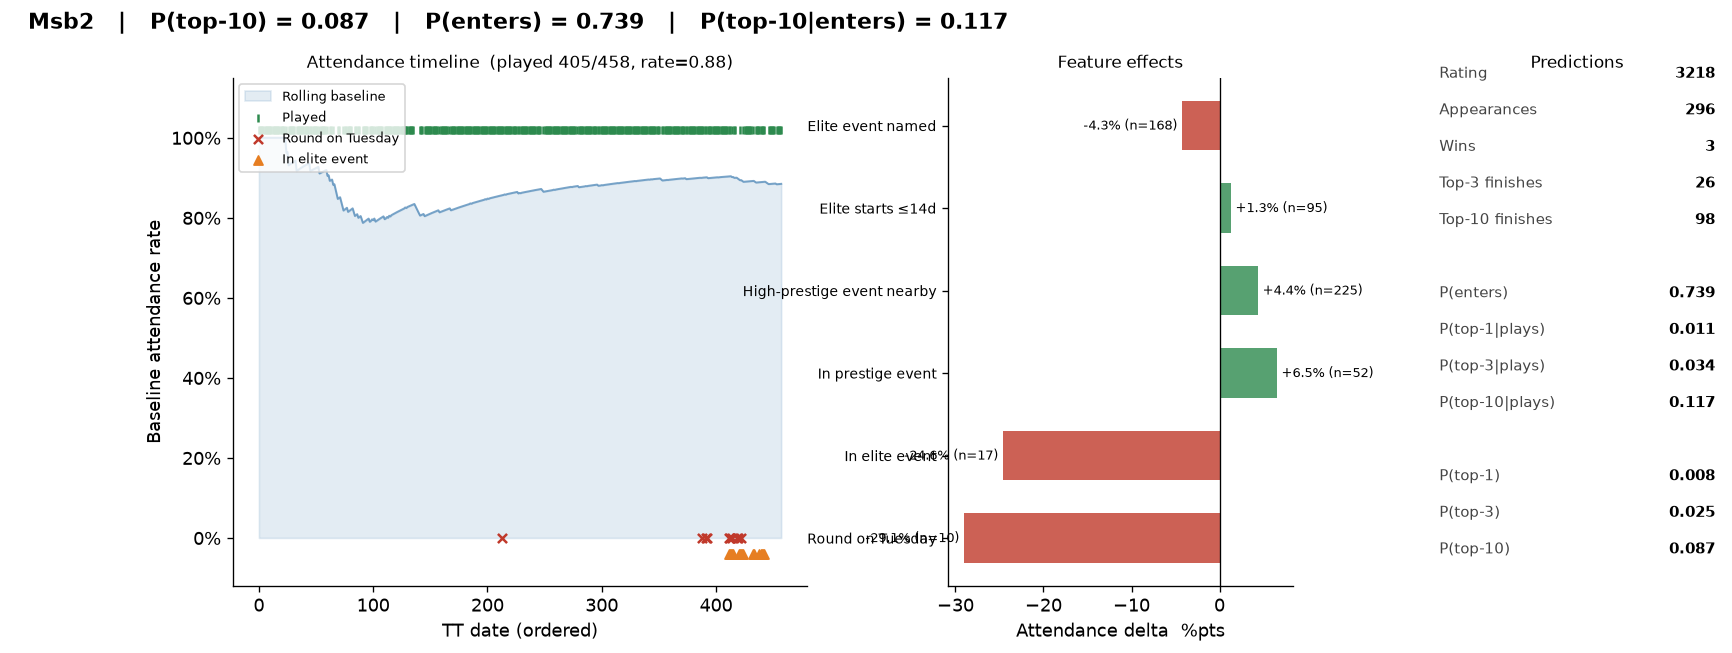

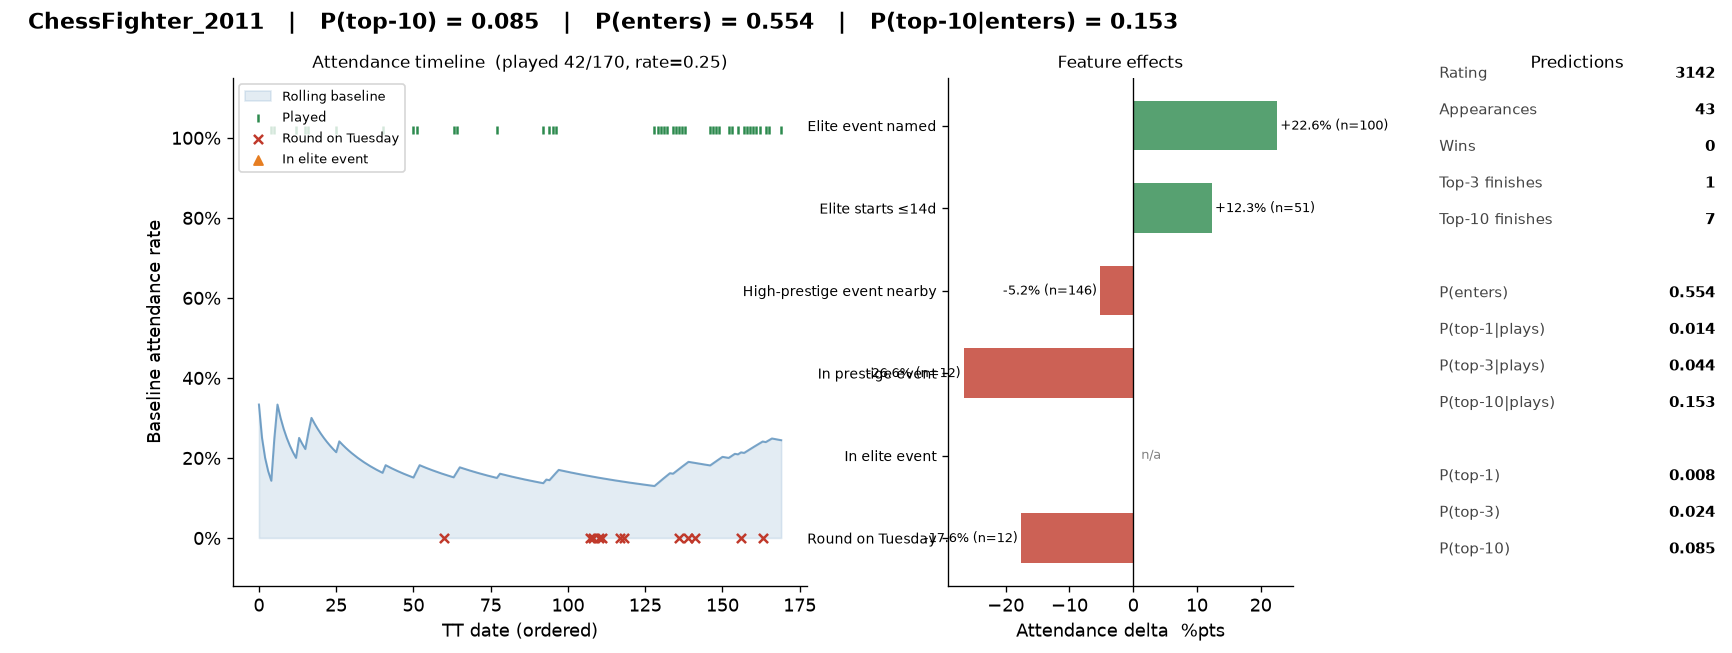

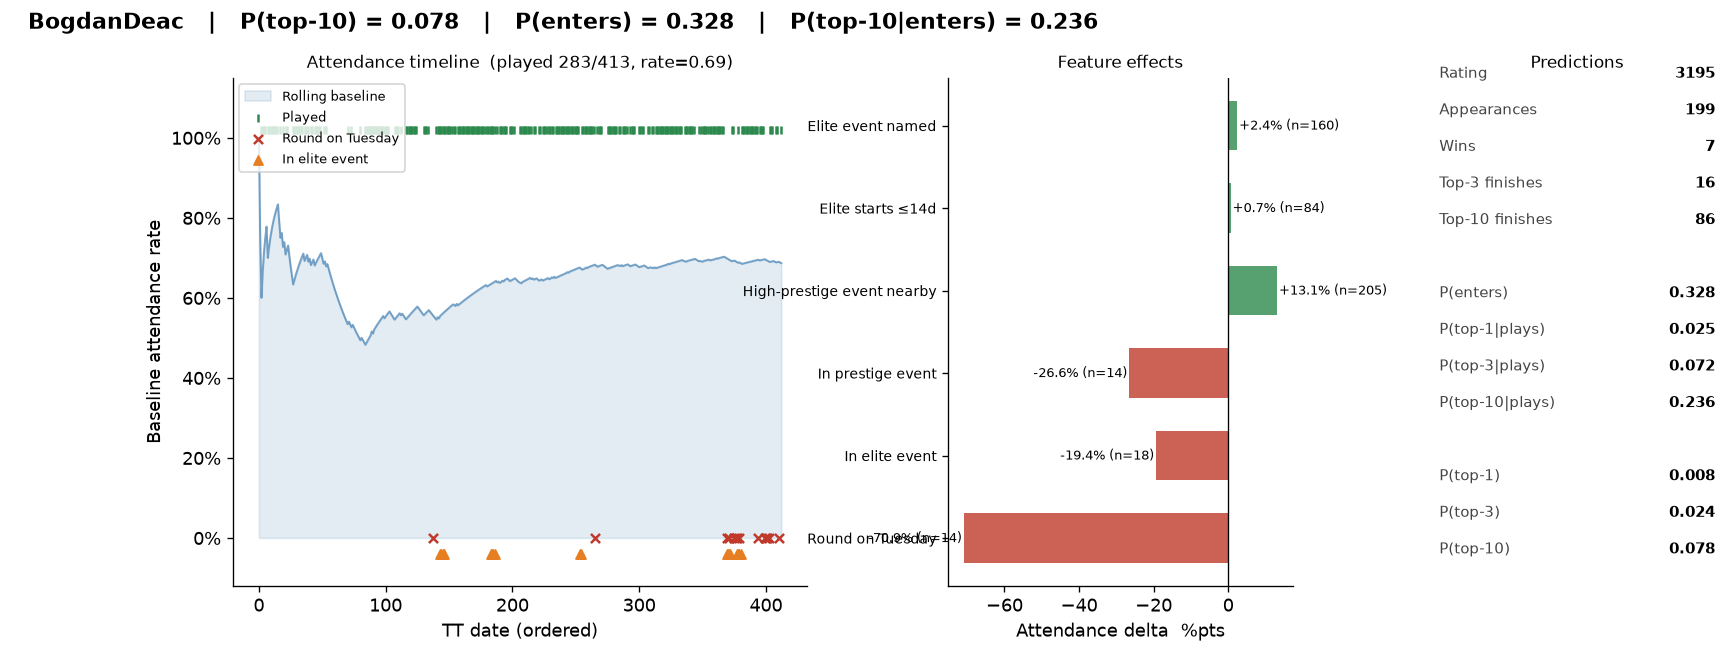

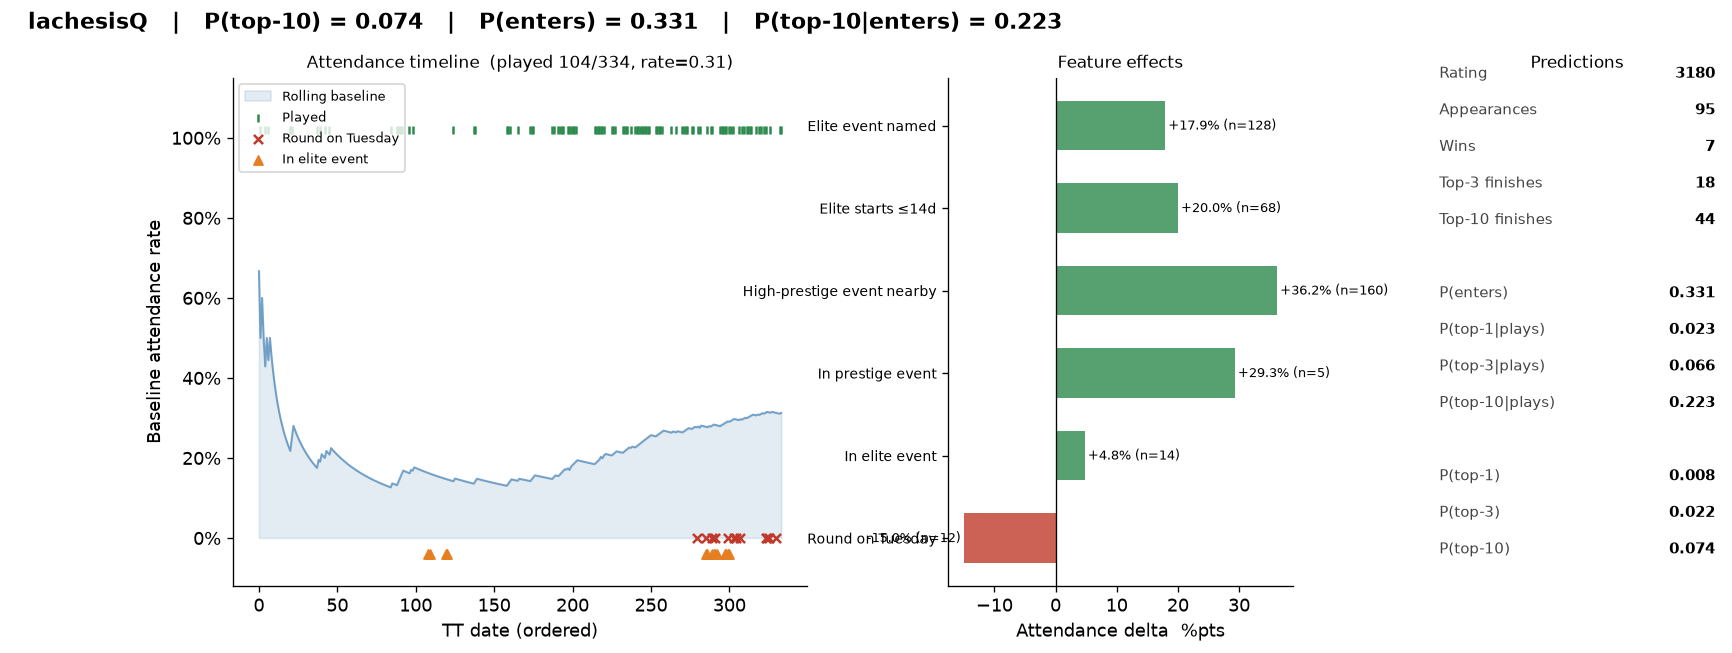

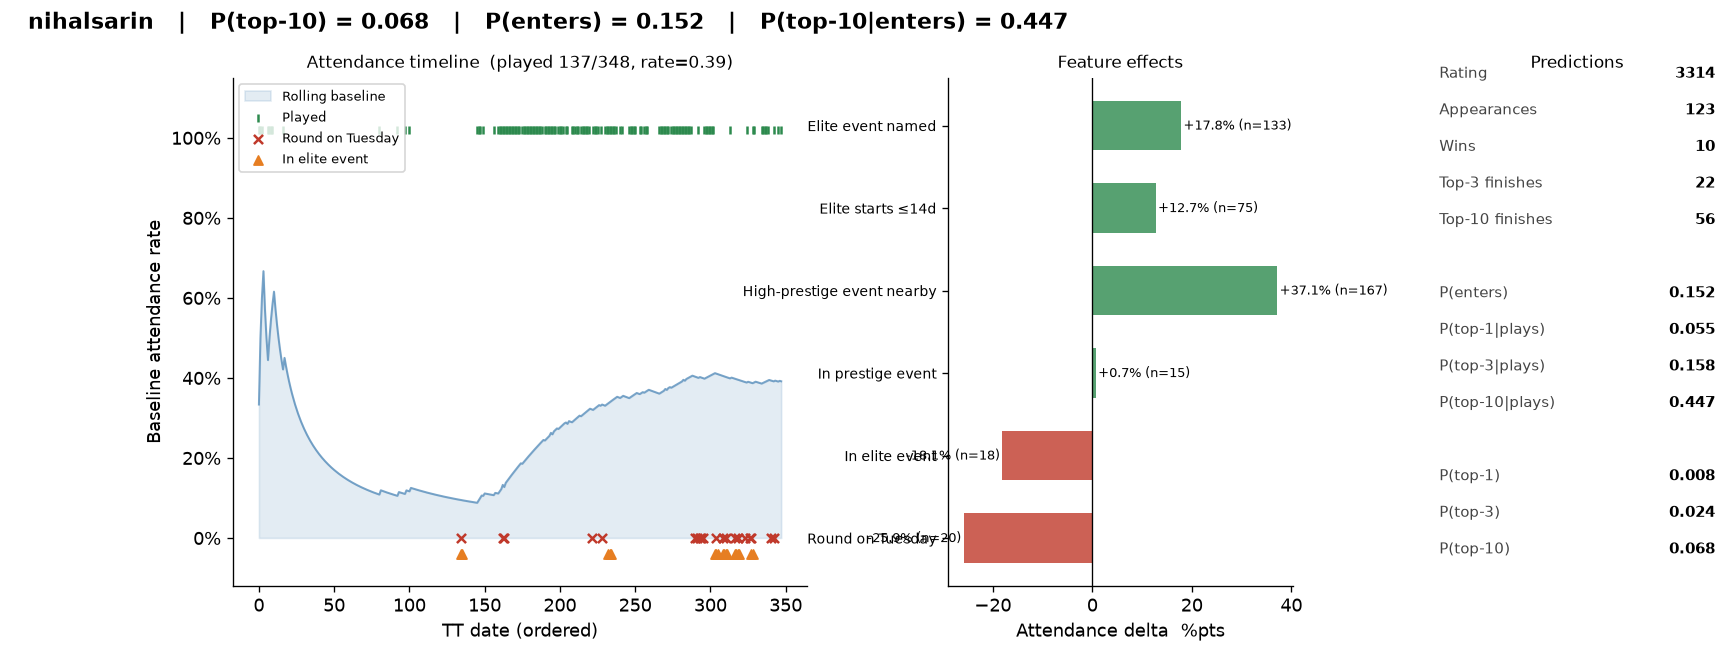

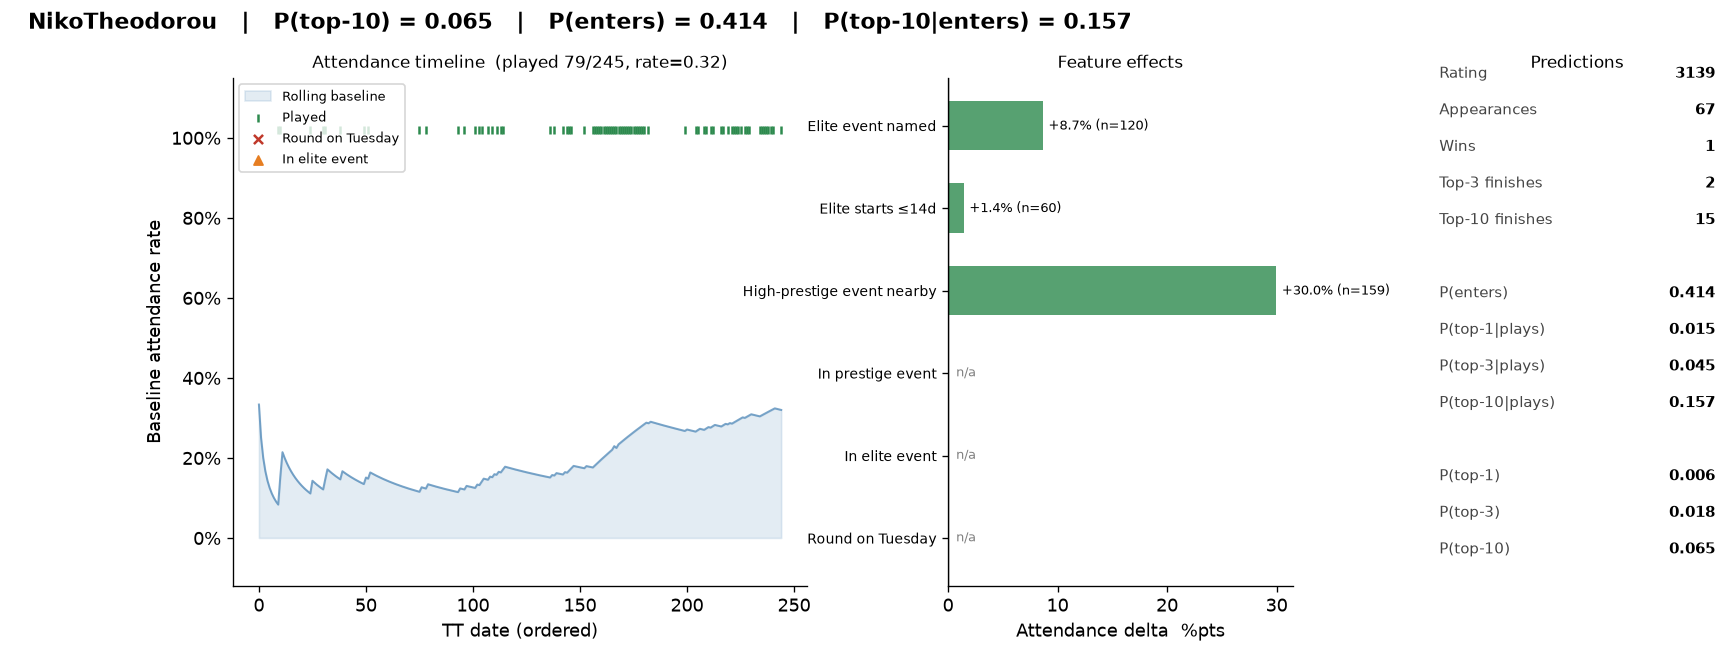

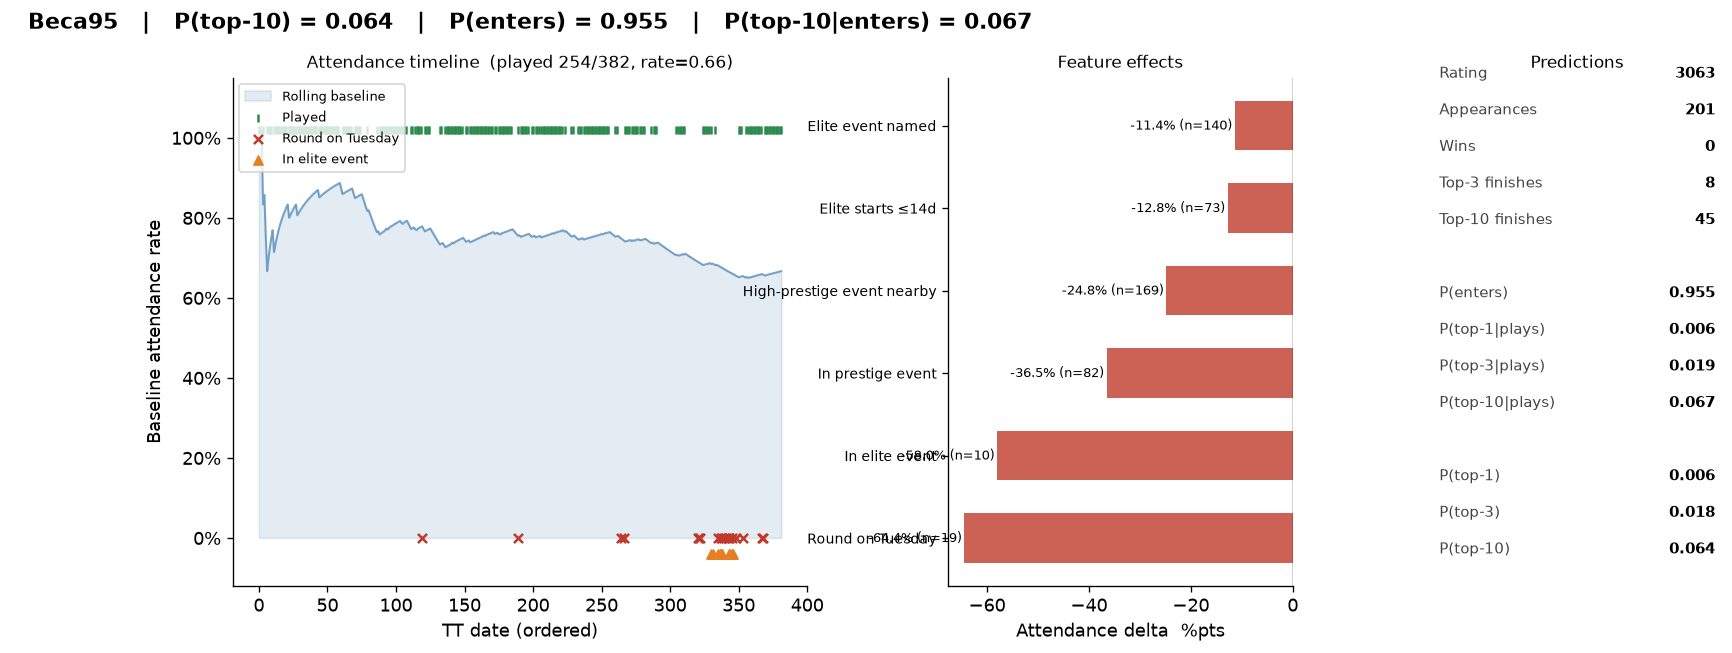

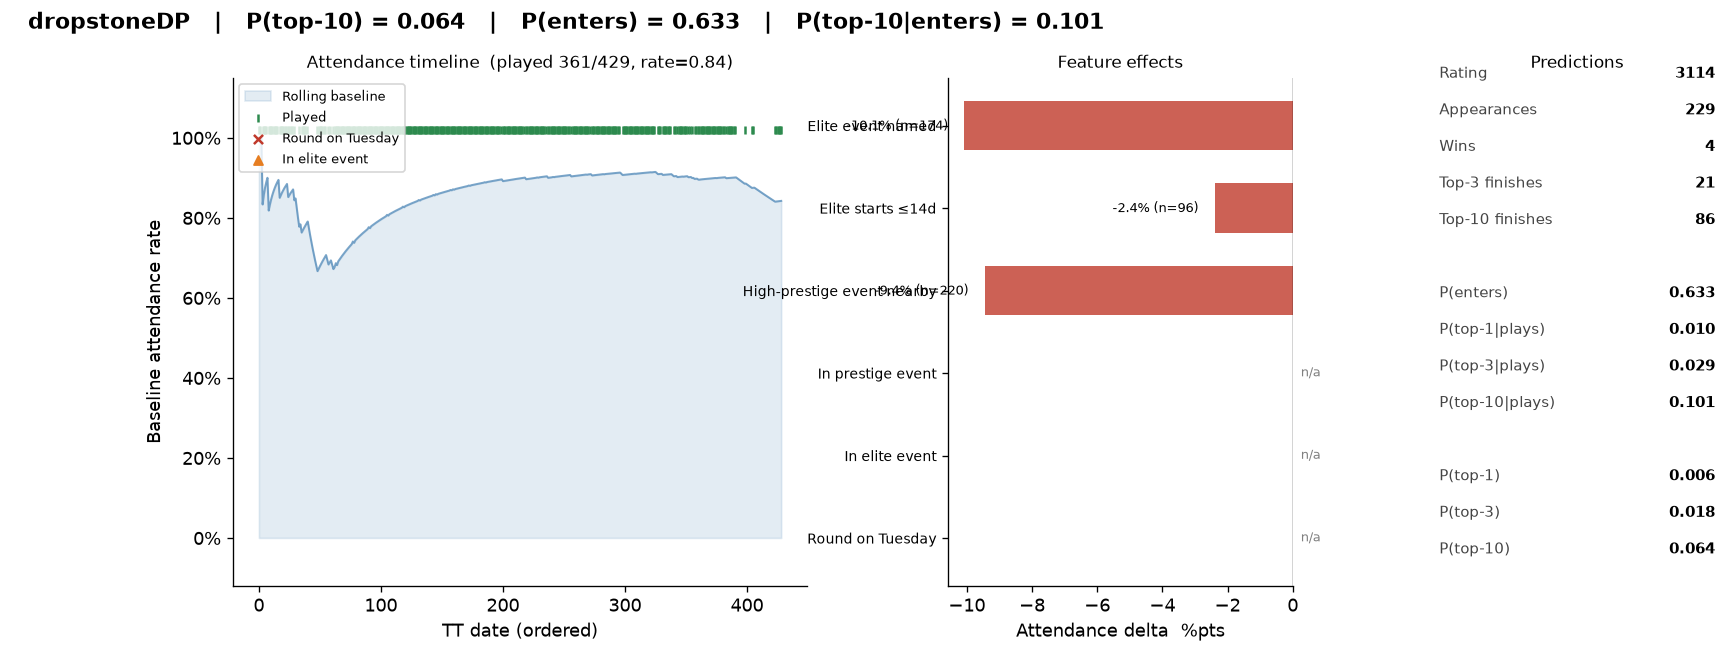

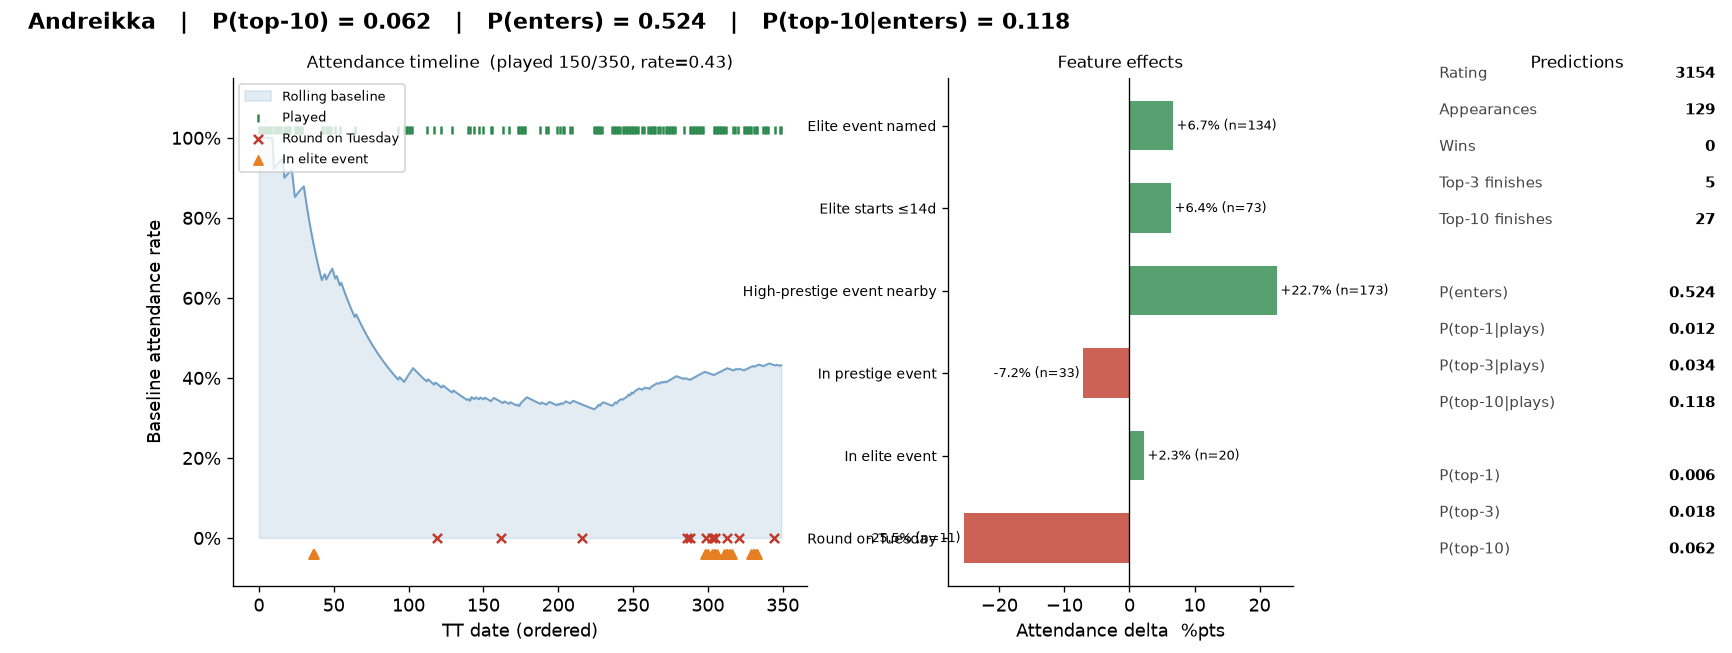

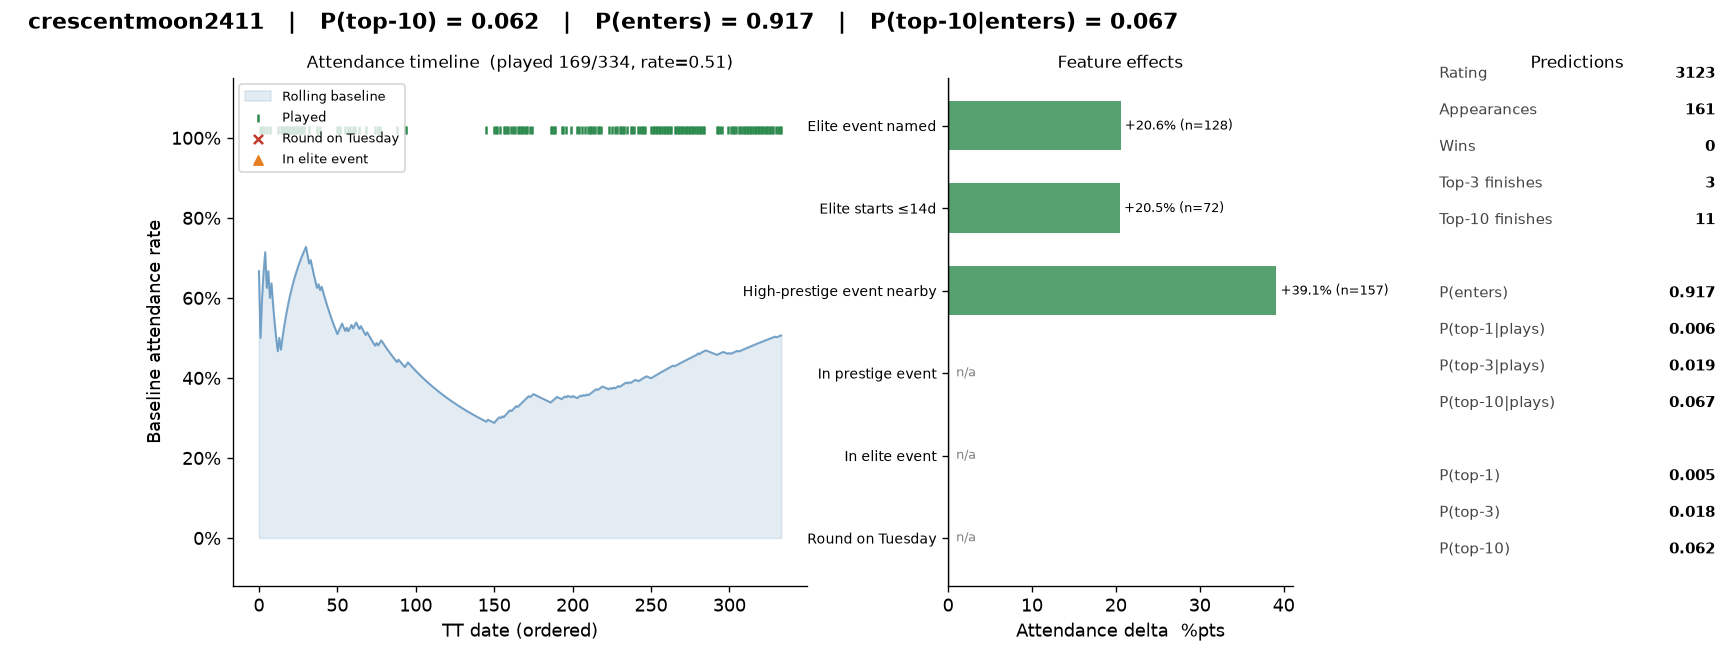

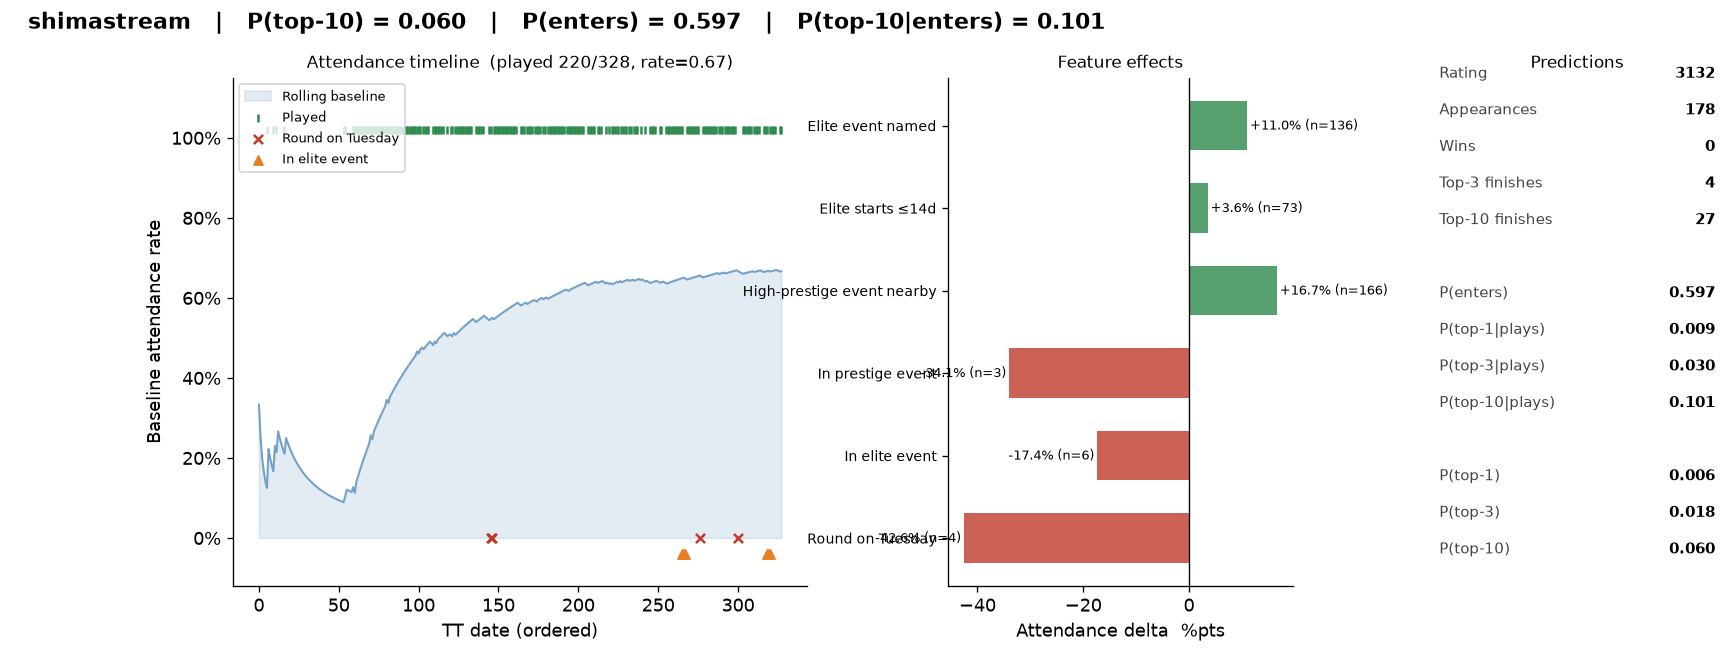

  Fedoseev-Vladimir: no eligible pool rows (< 8 appearances)


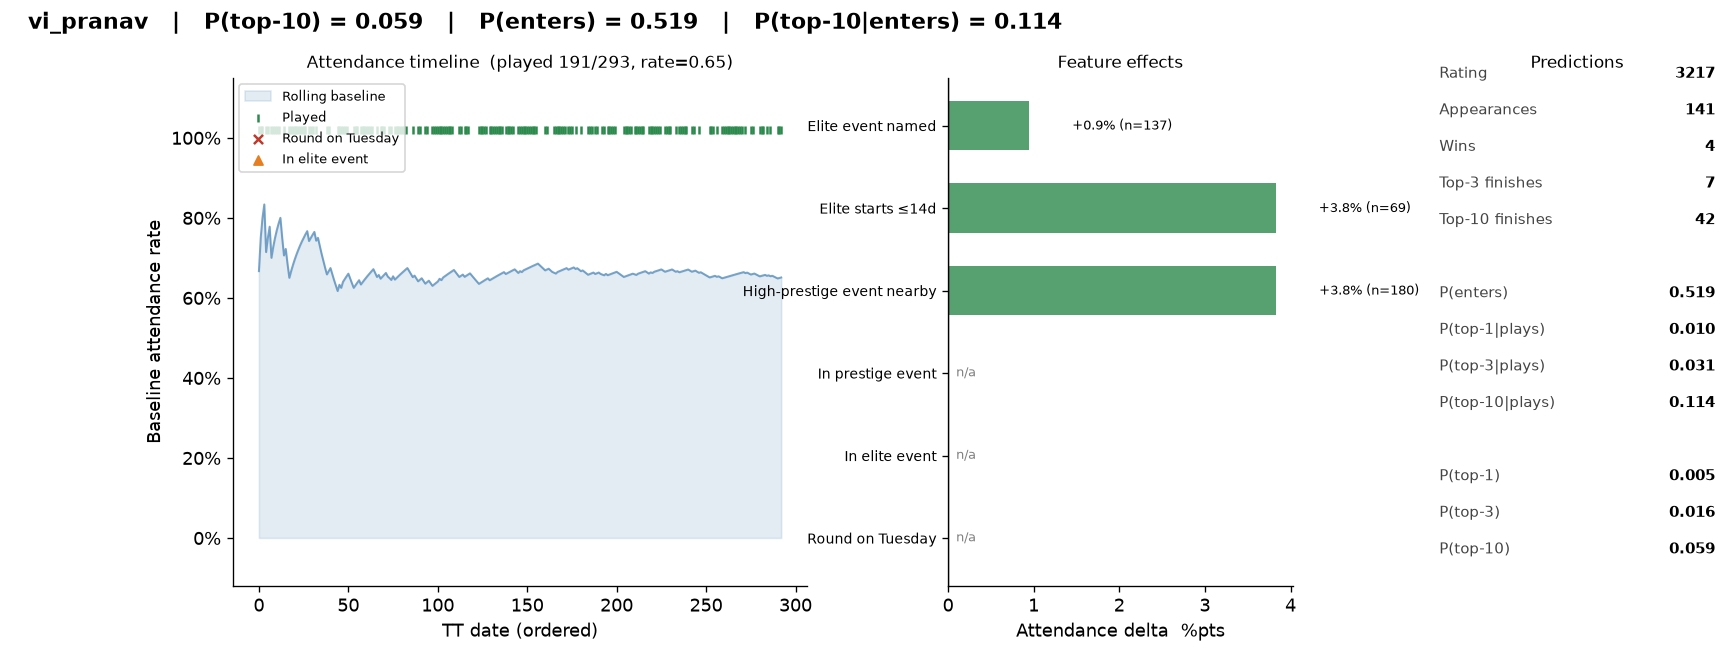

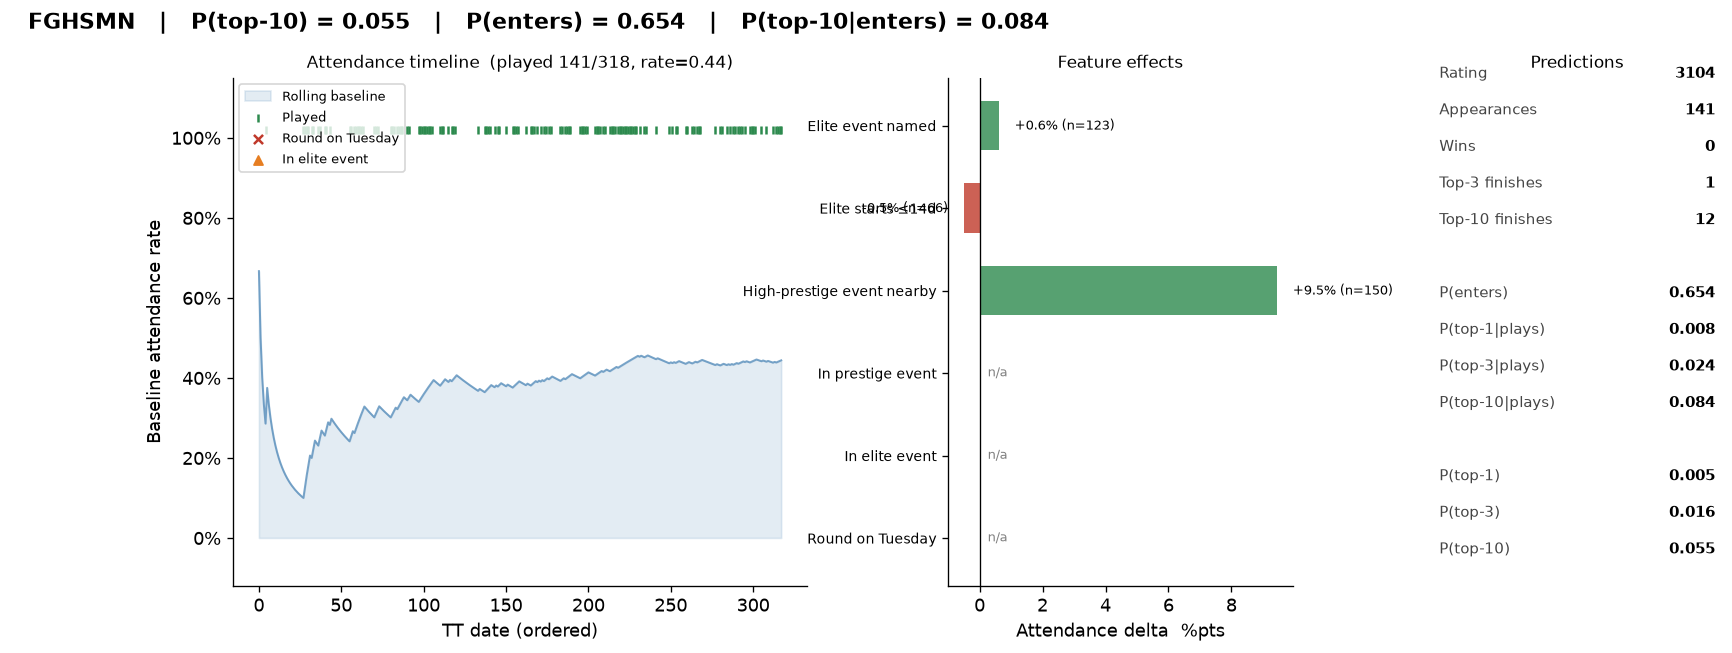

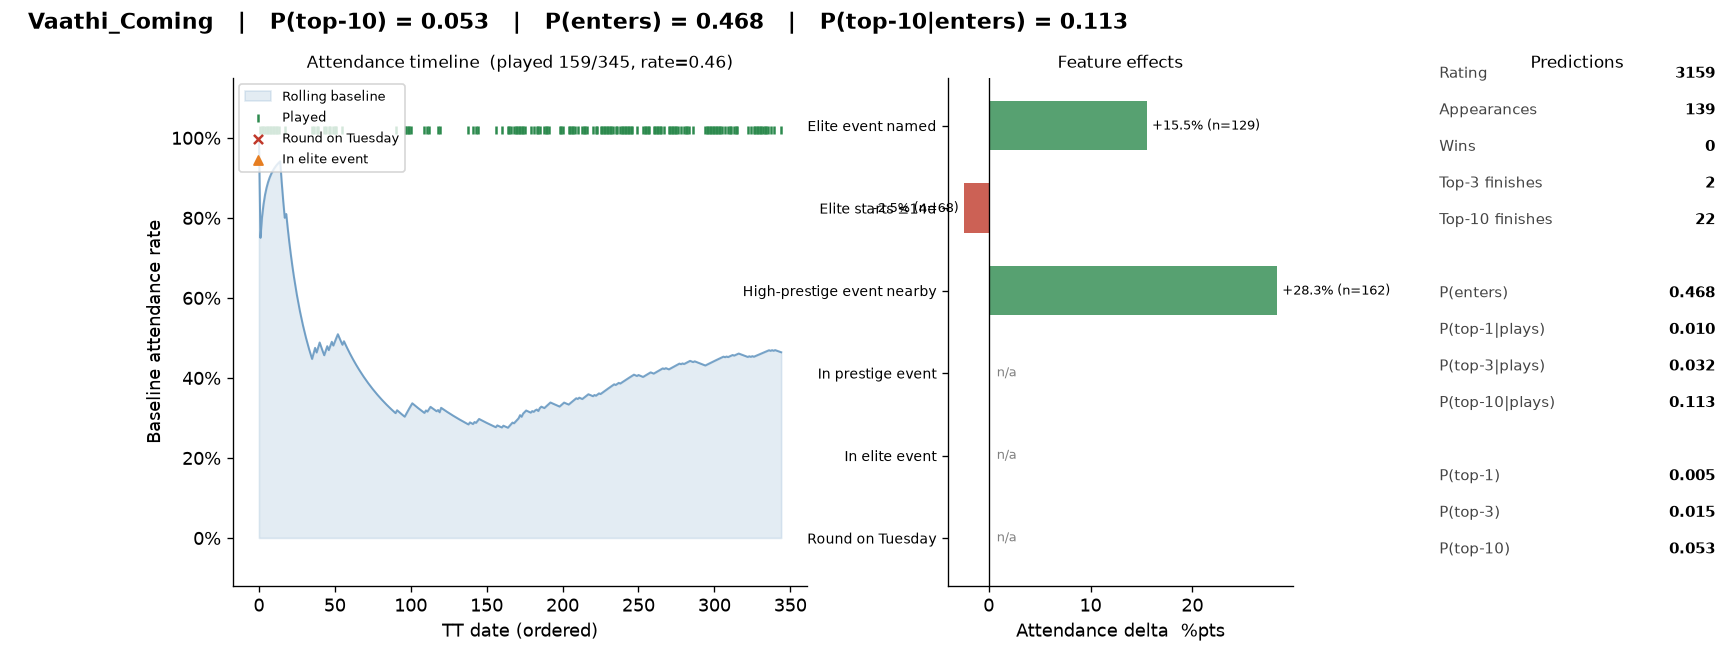

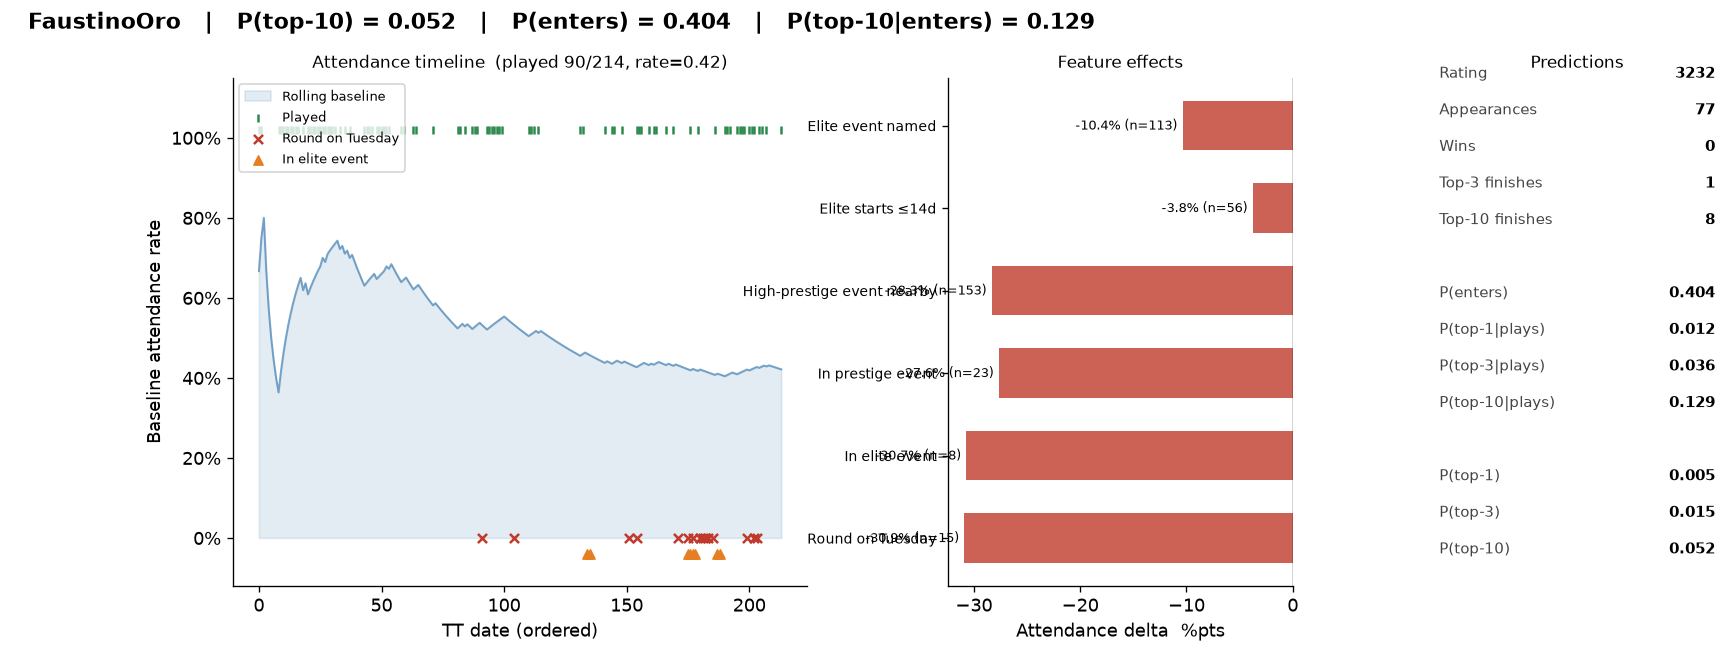

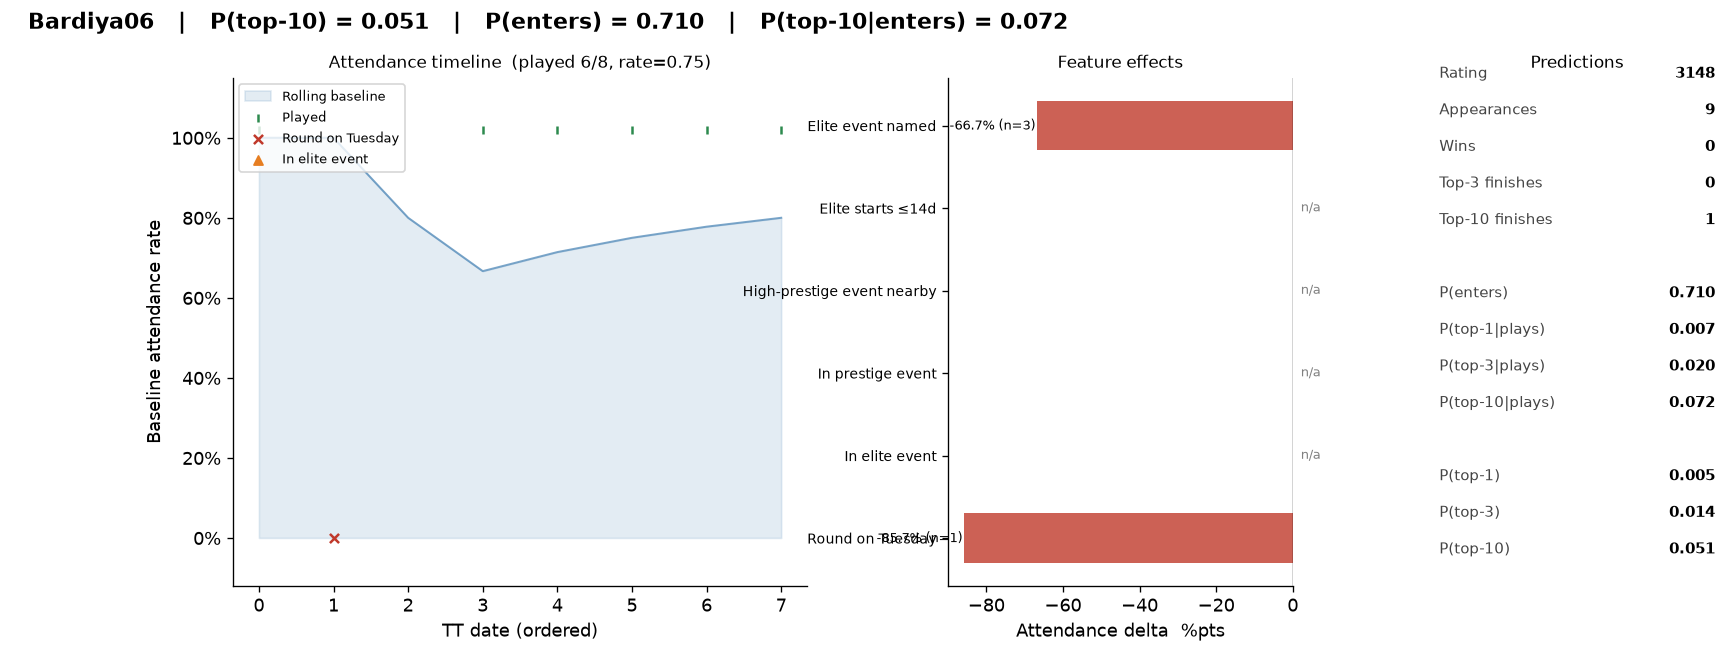

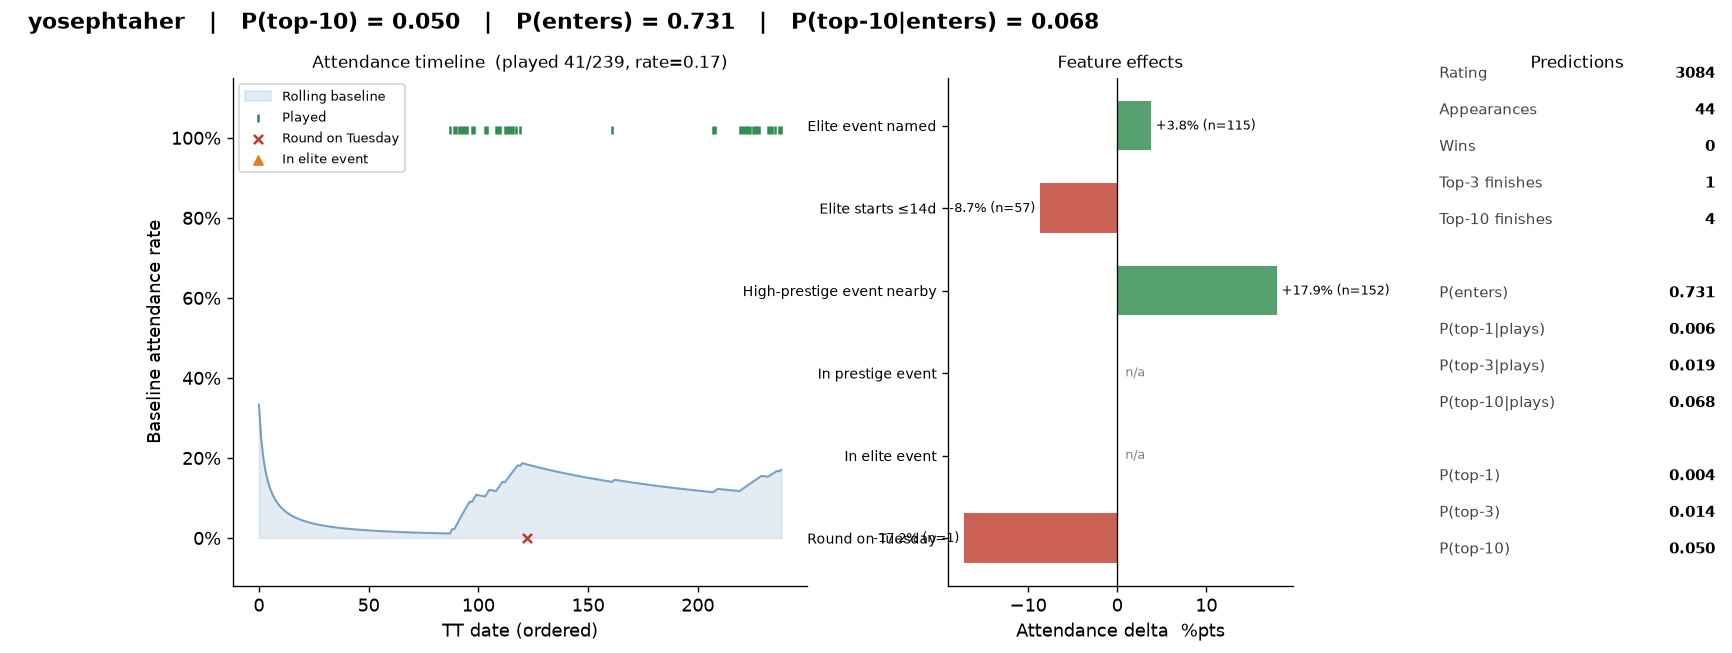

In [8]:
# Render a card for every shortlist player (sorted by P(top-10) desc)
for username in shortlist['username']:
    player_card(username, df_sl, df_hist, shortlist, app_counts, df_events, df_rounds, df_parts_matched)

## 5  Deep-dive: attendance sensitivity summary

For each shortlist player × broadcast feature, the attendance rate when active vs not.  
Useful for identifying which players are most affected.

In [9]:
FOCUS_FEATURES = ['player_round_tuesday', 'player_in_elite', 'n_high_prestige']
FOCUS_LABELS   = ['Round on Tuesday', 'In elite event', 'High-prestige event nearby']

summary_rows = []
for username in shortlist['username']:
    pdata = df_sl[df_sl['username'] == username]
    if pdata.empty:
        continue
    row = {'username': username,
           'p_top10': shortlist.loc[shortlist['username']==username, 'p_top10'].iloc[0],
           'base_rate': pdata['participated'].mean(),
           'n_obs': len(pdata)}
    for col, label in zip(FOCUS_FEATURES, FOCUS_LABELS):
        g0 = pdata[pdata[col] == 0]
        g1 = pdata[pdata[col] >= 1]
        row[f'{col}_n1']    = len(g1)
        row[f'{col}_rate1'] = g1['participated'].mean() if len(g1) >= 3 else np.nan
        row[f'{col}_delta'] = (g1['participated'].mean() - g0['participated'].mean()) if len(g1) >= 3 and len(g0) >= 3 else np.nan
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).sort_values('p_top10', ascending=False).reset_index(drop=True)

# Display: round-on-tuesday deltas
pd.set_option('display.float_format', '{:.3f}'.format)
show_cols = ['username', 'p_top10', 'base_rate', 'n_obs'] + \
            [c for feat in FOCUS_FEATURES for c in [f'{feat}_n1', f'{feat}_delta']]
df_summary[show_cols]

,username,p_top10,base_rate,n_obs,player_round_tuesday_n1,player_round_tuesday_delta,player_in_elite_n1,player_in_elite_delta,n_high_prestige_n1,n_high_prestige_delta
0,Hikaru,0.451,0.876,451,7,-0.164,27,-0.144,217,0.026
1,mishanick,0.359,0.910,454,0,NaN,0,NaN,220,0.078
2,DenLaz,0.330,0.742,364,3,-0.076,5,-0.144,178,0.088
3,GHANDEEVAM2003,0.316,0.436,358,2,NaN,4,-0.188,179,0.402
4,Polish_fighter3000,0.285,0.519,368,5,-0.121,7,-0.238,193,0.456
5,HansOnTwitch,0.236,0.391,325,0,NaN,0,NaN,182,0.361
6,ChristopherYoo,0.210,0.545,356,0,NaN,0,NaN,178,-0.034
7,jefferyx,0.204,0.780,418,4,-0.283,8,-0.540,209,0.124
8,Parhamov,0.202,0.530,364,23,-0.055,18,0.202,173,0.003
9,FairChess_on_YouTube,0.189,0.884,449,3,-0.555,3,0.117,203,-0.058


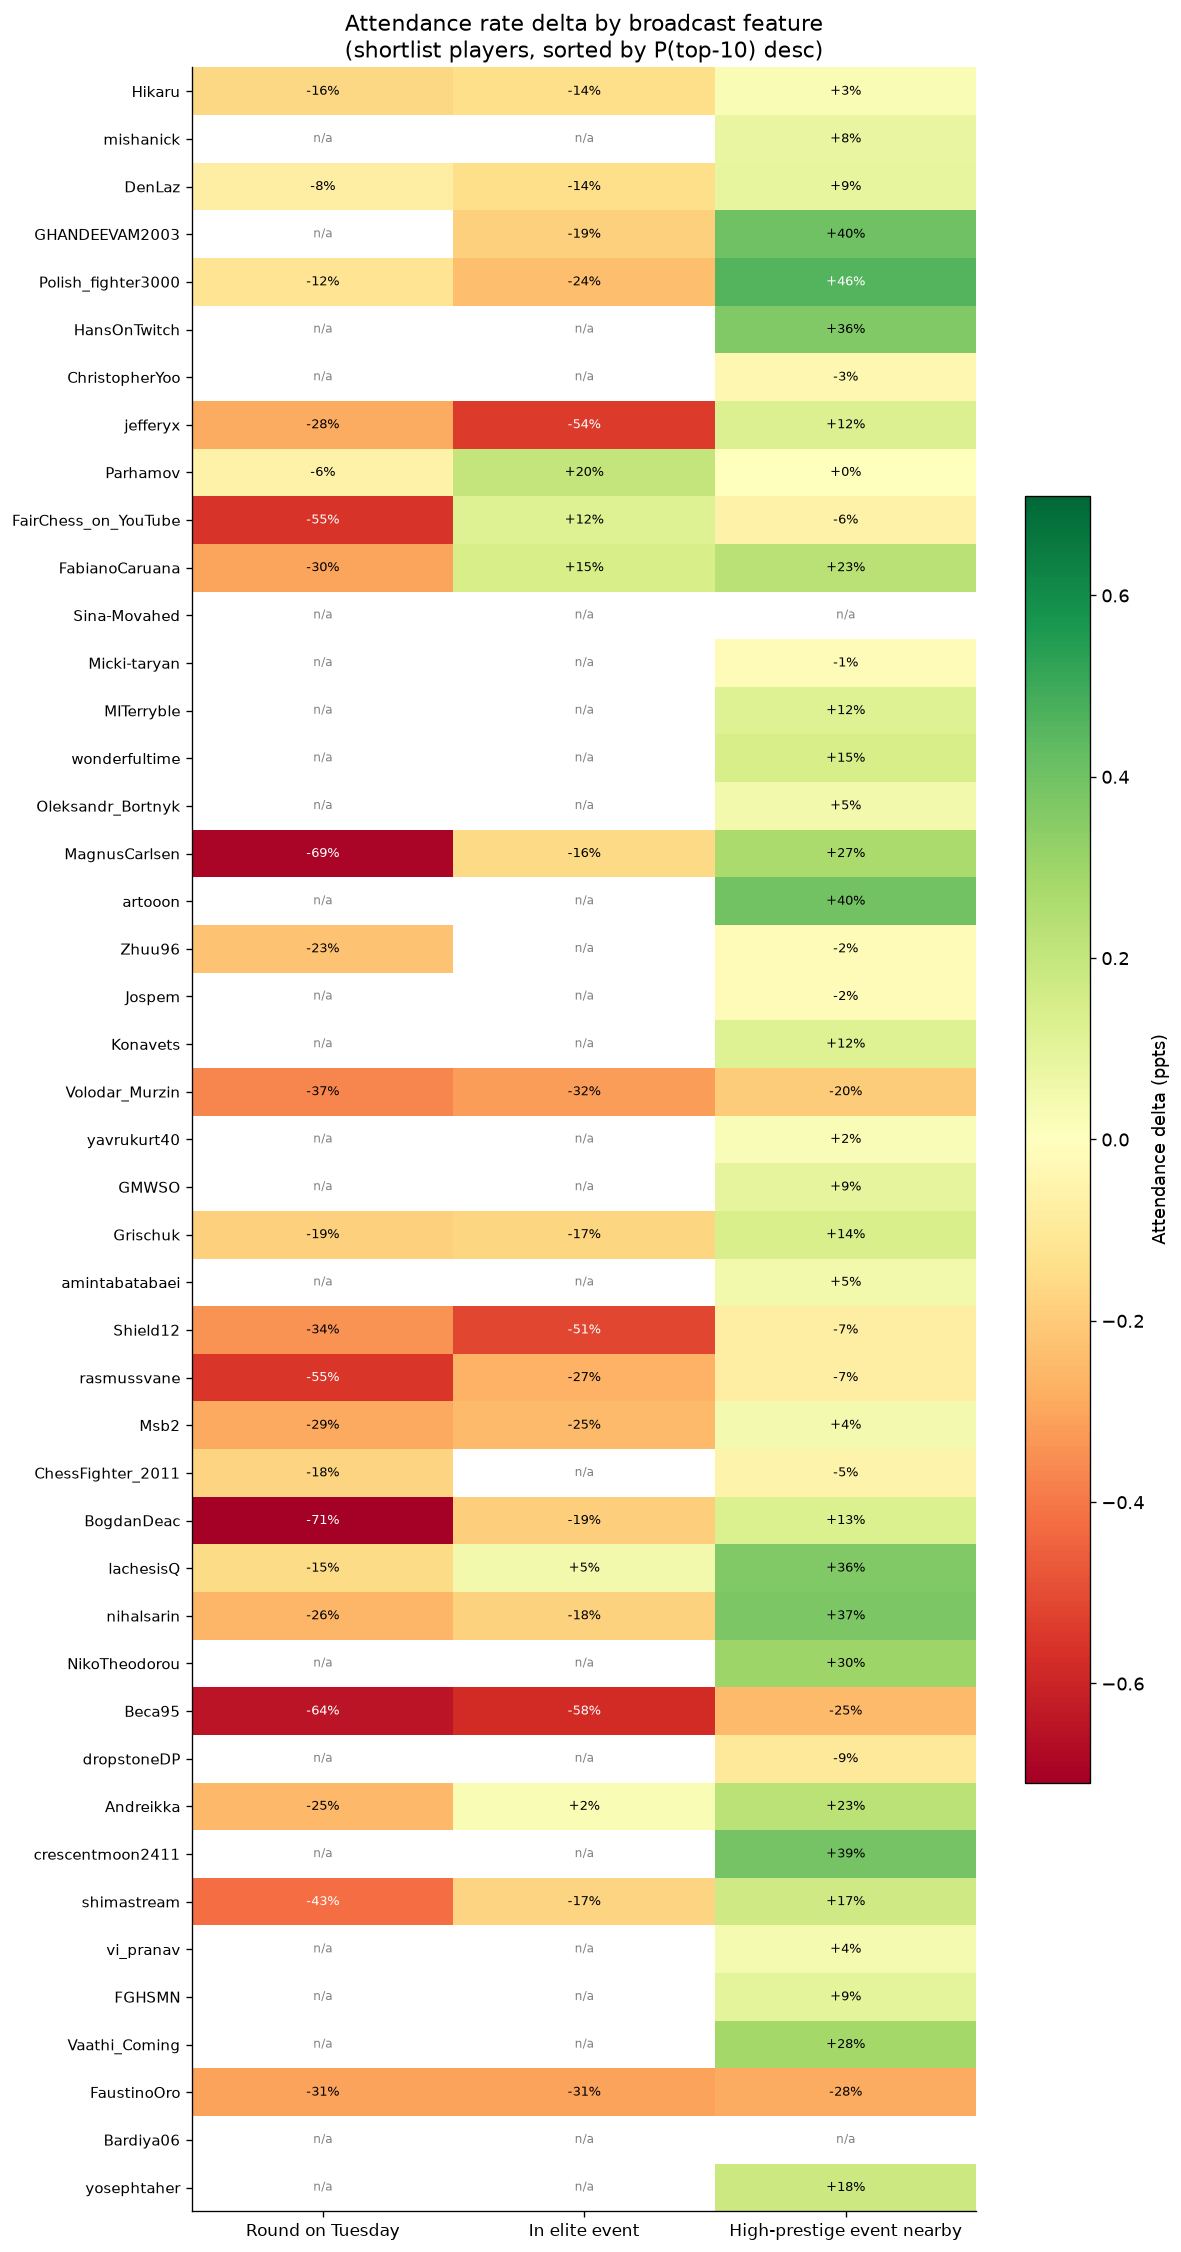

In [10]:
# Heatmap: attendance delta per (player, feature)
delta_cols = [f'{c}_delta' for c in FOCUS_FEATURES]
heat = df_summary.set_index('username')[delta_cols].copy()
heat.columns = FOCUS_LABELS

fig, ax = plt.subplots(figsize=(10, max(5, len(heat) * 0.42)))
import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn  # red=negative, green=positive
vmax = heat.abs().max().max()

im = ax.imshow(heat.values.astype(float), cmap=cmap,
               vmin=-vmax, vmax=vmax, aspect='auto')

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, fontsize=10)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=9)

for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        val = heat.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val*100:+.0f}%', ha='center', va='center',
                    fontsize=8, color='black' if abs(val) < vmax * 0.6 else 'white')
        else:
            ax.text(j, i, 'n/a', ha='center', va='center', fontsize=7, color='gray')

plt.colorbar(im, ax=ax, shrink=0.6, label='Attendance delta (ppts)')
ax.set_title('Attendance rate delta by broadcast feature\n(shortlist players, sorted by P(top-10) desc)')
plt.tight_layout()
plt.show()

## 6  Opportunism: attendance when shortlist peers have Tuesday conflicts

For each shortlist player, restricted to TT dates when **they do not have a broadcast conflict**,
we regress attendance on `n_top_conflicted` — the count of other shortlist players who *do* have
a broadcast round that Tuesday.

* **Opportunism r**: Pearson correlation between attendance and n_top_conflicted.
  Positive = shows up more when peers are absent (opportunistic).
* **Slope (pp/player)**: OLS coefficient — how many percentage points P(attend) changes
  for each additional conflicted top player.

Significance markers: \* p<0.10  \*\* p<0.05  \*\*\* p<0.01

In [ ]:
from scipy import stats

# Per TT date: count shortlist players (from full broadcast-matched data)
# who have a broadcast round on that Tuesday.
# Using df_player_feats (not just the eligible pool) avoids selection bias.
sl_round_per_date = (
    df_player_feats[df_player_feats['username'].isin(shortlist_users)]
    .groupby('date')['player_round_tuesday']
    .sum()
    .rename('n_top_conflicted')
    .reset_index()
)

df_sl_opp = df_sl.merge(sl_round_per_date, on='date', how='left')
df_sl_opp['n_top_conflicted'] = df_sl_opp['n_top_conflicted'].fillna(0).astype(int)

# Distribution of peer-conflict counts across non-conflict rows
nc = df_sl_opp[df_sl_opp['player_round_tuesday'] == 0]['n_top_conflicted']
print('n_top_conflicted distribution (non-conflict rows):')
print(nc.value_counts().sort_index().head(12).to_string())
print(f'\nMean: {nc.mean():.2f}  Median: {nc.median():.1f}  Max: {nc.max()}')

# Per-player: Pearson r and OLS slope on non-conflict dates only
opp_rows = []
for username in shortlist['username']:
    pdata = df_sl_opp[
        (df_sl_opp['username'] == username) &
        (df_sl_opp['player_round_tuesday'] == 0)
    ]
    n_obs  = len(pdata)
    n_conf = int((pdata['n_top_conflicted'] > 0).sum())
    x = pdata['n_top_conflicted'].values.astype(float)
    y = pdata['participated'].values.astype(float)
    if n_obs < 10 or x.std() < 0.01:
        r, slope, p_val = np.nan, np.nan, np.nan
    else:
        r, p_val = stats.pearsonr(x, y)
        # OLS slope: ppt change in P(attend) per extra conflicted top player
        slope = np.cov(x, y)[0, 1] / np.var(x) * 100
    opp_rows.append({
        'username': username,
        'n_nonconflict': n_obs,
        'n_peer_conflict_dates': n_conf,
        'opportunism_r': r,
        'opportunism_slope_ppt': slope,
        'p_value': p_val,
    })

df_opp = pd.DataFrame(opp_rows).merge(
    shortlist[['username', 'p_top10', 'p_participate']], on='username'
)
df_opp['sig'] = df_opp['p_value'].apply(
    lambda p: ('***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '')))
    if pd.notna(p) else ''
)
df_opp = df_opp.sort_values('opportunism_r', ascending=False).reset_index(drop=True)

pd.set_option('display.float_format', '{:.3f}'.format)
cols = ['username', 'p_top10', 'p_participate', 'n_nonconflict',
        'n_peer_conflict_dates', 'opportunism_r', 'opportunism_slope_ppt', 'p_value', 'sig']
df_opp[cols]

In [ ]:
# Bar chart of opportunism_r, sorted ascending for horizontal bars
df_plot = df_opp.dropna(subset=['opportunism_r']).sort_values('opportunism_r', ascending=True).reset_index(drop=True)
colors = ['#2d8a4e' if r >= 0 else '#c0392b' for r in df_plot['opportunism_r']]

fig, ax = plt.subplots(figsize=(11, max(5, len(df_plot) * 0.38)))
ax.barh(range(len(df_plot)), df_plot['opportunism_r'], color=colors, alpha=0.82, height=0.7)

for i, row in df_plot.iterrows():
    r     = row['opportunism_r']
    sig   = row['sig']
    slope = row['opportunism_slope_ppt']
    ax.text(r + (0.004 if r >= 0 else -0.004), i,
            f'{r:+.3f}  ({slope:+.1f} pp/player){sig}',
            va='center', ha='left' if r >= 0 else 'right', fontsize=8)

ax.set_yticks(range(len(df_plot)))
ax.set_yticklabels(df_plot['username'], fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson r  (attendance vs. n shortlist peers with Tuesday conflict)')
ax.set_title(
    'Opportunism: do elite players attend more when top peers are absent?\n'
    '(non-conflict dates only; bar label = slope in pp/extra conflicted player)'
)
plt.tight_layout()
plt.show()